# Gráficos — Atividade 01 (IA001)

Notebook separado, só para gerar os gráficos das perguntas de análise.

**Dataset:** `dataset_principal.csv` — Atlas do Desenvolvimento Humano no Brasil (Pnud, Ipea, FJP).

Os dados são carregados direto do [repositório público](https://github.com/valandro/ufrgs-spec-ai), então o notebook é executável de forma independente.

## 0. Configuração do ambiente

Execute esta seção **uma vez**, antes de qualquer outra célula.

| Pacote | Mínimo | Por que esta versão |
|---|---|---|
| `pandas` | 1.5 | `groupby(..., observed=True)` usado nos agrupamentos por quartil e por região |
| `numpy` | 1.20 | `np.random.default_rng` (jitter e teste de permutação) |
| `matplotlib` | 3.4 | `ax.spines[["top", "right"]]` — indexação de spines por lista |
| `scipy` | 1.7 | `stats.linregress`, `pearsonr` e `spearmanr` |

`re`, `pathlib` e `importlib.metadata` são da biblioteca padrão e não precisam de instalação.

**Dados.** Os CSVs são lidos **direto do repositório público no GitHub**, então este notebook roda sozinho, em qualquer pasta, sem precisar do restante do projeto. O `pandas` aceita URL diretamente em `read_csv`.

| Arquivo | Conteúdo | Usado em |
|---|---|---|
| `educacao/dataset_principal.csv` | Atlas do Desenvolvimento Humano no Brasil (Pnud, Ipea, FJP) | todas as perguntas |
| `atlas/municipios_regioes_funcionais_rs.csv` | Regiões Funcionais de Planejamento do RS (COREDEs) | perguntas 4, 6 e 8 |

Repositório: [https://github.com/valandro/ufrgs-spec-ai](https://github.com/valandro/ufrgs-spec-ai)

As URLs ficam em `BASE_DADOS`, na célula abaixo. Para trabalhar **offline** ou com uma cópia local, basta apontar essa constante para a pasta do projeto (`BASE_DADOS = "../../"`) — o resto do notebook não muda.

**Reprodutibilidade:** a URL aponta para o branch `main`, então o notebook sempre lê a versão mais recente dos dados. Para congelar exatamente a versão usada nesta análise, substitua `main` pelo hash do commit.

A segunda célula confere as versões dos pacotes e se as duas URLs respondem. Só imprime um relatório — não interrompe a execução.

In [ ]:
# Instalação das dependências no MESMO ambiente em que este kernel roda.
#
# Use %pip (magia do Jupyter), e não !pip. O "!" chama o pip do shell, que pode
# apontar para outro Python que não o do kernel — é a causa mais comum de
# "instalei e continua dando ModuleNotFoundError". O %pip sempre instala no
# interpretador do kernel ativo.
#
# Rode esta célula uma vez. Se os pacotes já estiverem presentes nas versões
# mínimas, o pip não faz nada. Depois de instalar pela primeira vez,
# reinicie o kernel para garantir que as versões novas sejam carregadas.

%pip install --quiet "pandas>=1.5" "numpy>=1.20" "matplotlib>=3.4" "scipy>=1.7"

In [ ]:
# Verificação: as dependências importam mesmo, e os dados estão acessíveis.
# Roda rápido e não interrompe o notebook — só relata o que está fora do lugar.
#
# A checagem IMPORTA cada pacote em vez de apenas consultar os metadados do pip.
# Metadado presente não garante import funcionando (instalação corrompida,
# extensão compilada incompatível com a versão do Python, etc.), e é o import
# que o notebook precisa.
import re
from importlib import import_module
from urllib.request import urlopen
from urllib.error import URLError, HTTPError

VERSOES_MINIMAS = {
    "pandas": "1.5",       # groupby(observed=True) respeitado
    "numpy": "1.20",       # np.random.default_rng
    "matplotlib": "3.4",   # ax.spines[["top", "right"]] (indexação por lista)
    "scipy": "1.7",        # stats.linregress / pearsonr / spearmanr
}

# ---------------------------------------------------------------
# Origem dos dados: repositório público no GitHub
# ---------------------------------------------------------------
# Os CSVs são lidos por URL para que este notebook rode sozinho, sem precisar
# do restante do projeto. O pandas aceita URL diretamente em read_csv.
#
# Para trabalhar offline ou com uma cópia local, troque BASE_DADOS pelo
# caminho relativo da pasta do projeto:
#     BASE_DADOS = "../../"
#
# Nota de reprodutibilidade: a URL aponta para o branch "main", então o
# notebook sempre lê a versão mais recente dos dados. Para congelar a versão
# usada nesta análise, troque "main" pelo hash do commit.
BASE_DADOS = "https://raw.githubusercontent.com/valandro/ufrgs-spec-ai/main/AI001-analise-visualizacao-dados/"

URL_DATASET_PRINCIPAL = BASE_DADOS + "educacao/dataset_principal.csv"
URL_REGIOES_FUNCIONAIS = BASE_DADOS + "atlas/municipios_regioes_funcionais_rs.csv"

FONTES_DE_DADOS = {
    URL_DATASET_PRINCIPAL:
        "Atlas do Desenvolvimento Humano — usado em todas as perguntas",
    URL_REGIOES_FUNCIONAIS:
        "Regiões Funcionais do RS — usado nas perguntas 4, 6 e 8",
}


def _numeros(v):
    """'2.3.3rc1' -> (2, 3, 3). Compara só a parte numérica da versão."""
    return tuple(int(p) for p in re.findall(r"\d+", v)[:3])


problemas = []

print("Pacotes:")
for pacote, minimo in VERSOES_MINIMAS.items():
    try:
        modulo = import_module(pacote)
    except ImportError as erro:
        print(f"  [FALTA]  {pacote:12s} não importa ({erro})")
        problemas.append(pacote)
        continue
    instalada = getattr(modulo, "__version__", "desconhecida")
    if instalada == "desconhecida" or _numeros(instalada) >= _numeros(minimo):
        print(f"  [ok]     {pacote:12s} {instalada:10s} (mínimo {minimo})")
    else:
        print(f"  [VELHO]  {pacote:12s} {instalada:10s} — abaixo do mínimo {minimo}")
        problemas.append(pacote)

print("\nFontes de dados:")
for url, descricao in FONTES_DE_DADOS.items():
    nome = url.rsplit("/", 1)[-1]
    if not url.startswith("http"):
        from pathlib import Path
        estado = "ok" if Path(url).exists() else "FALTA"
    else:
        try:
            with urlopen(url, timeout=20) as resposta:
                estado = "ok" if resposta.status == 200 else f"HTTP {resposta.status}"
        except (URLError, HTTPError, OSError) as erro:
            estado = f"inacessível ({erro})"
    if estado != "ok":
        problemas.append(nome)
    print(f"  [{estado}]{'' if estado == 'ok' else ' '}     {nome}")
    print(f"           {descricao}")

if problemas:
    print(f"\nPendências: {problemas}")
    print("Para pacotes: rode a célula de instalação acima e reinicie o kernel.")
    print("Para dados: confira a conexão de rede, ou aponte BASE_DADOS para uma cópia local.")
else:
    print("\nAmbiente pronto.")

## Preparação do ambiente

In [ ]:
# imports (pandas, matplotlib, etc.)
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

## Carregamento e limpeza dos dados

In [2]:
# URL definida na seção 0 (Configuração do ambiente).
# O pandas lê direto da URL, então o notebook roda sem o resto do projeto.
df = pd.read_csv(URL_DATASET_PRINCIPAL)
df = df.iloc[:-3]  # remove a linha em branco + as 2 linhas de crédito/fonte do rodapé

municipios = df[~df["Territorialidades"].isin(["Brasil", "Rio Grande do Sul"])].copy()

print(df.head())  # Display the first few rows of the DataFrame

   Territorialidades % dos ocupados com ensino médio completo 2010  \
0             Brasil                                         44.91   
1  Rio Grande do Sul                                         43.64   
2        Aceguá (RS)                                         21.42   
3    Água Santa (RS)                                         29.12   
4         Agudo (RS)                                         23.35   

   Rendimento médio dos ocupados 2010  % dos ocupados sem rendimento 2010  \
0                             1296.19                                5.58   
1                             1332.67                                5.04   
2                             1112.46                                2.78   
3                             1125.67                               15.46   
4                             1043.29                               10.95   

   % dos ocupados com rendimento de até 1 salário mínimo 2010  \
0                                              21.9

## Pergunta 1

Municípios onde mais ocupados têm ensino médio completo pagam melhor?

Municípios com os dois indicadores preenchidos: 496
Municípios com os dois indicadores preenchidos: 496


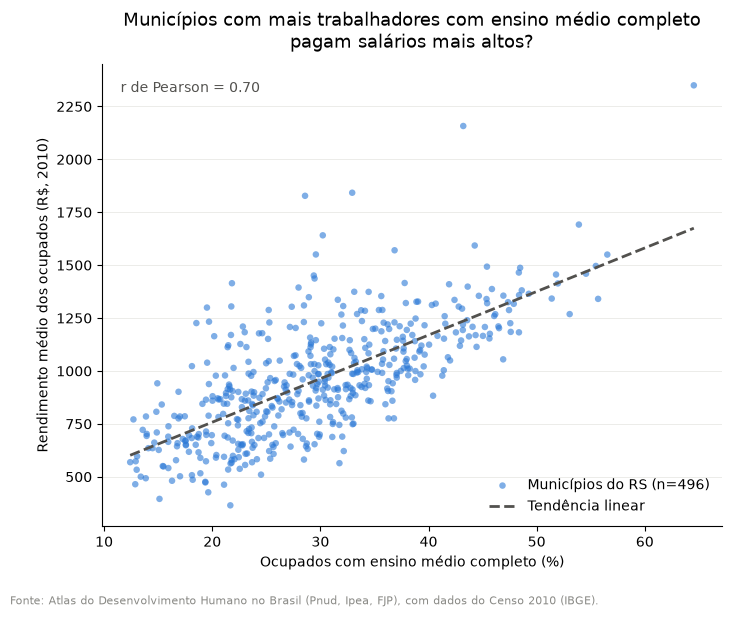

In [ ]:
# código do gráfico da pergunta 1
col_escolaridade = "% dos ocupados com ensino médio completo 2010"
col_renda = "Rendimento médio dos ocupados 2010"
 
for col in [col_escolaridade, col_renda]:
    municipios[col] = pd.to_numeric(municipios[col], errors="coerce")
 
municipios = municipios.dropna(subset=[col_escolaridade, col_renda])
print(f"Municípios com os dois indicadores preenchidos: {len(municipios)}")

col_escolaridade = "% dos ocupados com ensino médio completo 2010"
col_renda = "Rendimento médio dos ocupados 2010"
 
for col in [col_escolaridade, col_renda]:
    municipios[col] = pd.to_numeric(municipios[col], errors="coerce")
 
municipios = municipios.dropna(subset=[col_escolaridade, col_renda])
print(f"Municípios com os dois indicadores preenchidos: {len(municipios)}")
 
# ---------------------------------------------------------------
# 2. Estatística de apoio (reta de tendência e correlação)
# ---------------------------------------------------------------
slope, intercept, r, p, se = stats.linregress(
    municipios[col_escolaridade], municipios[col_renda]
)
x_linha = pd.Series([municipios[col_escolaridade].min(), municipios[col_escolaridade].max()])
y_linha = slope * x_linha + intercept
 
# ---------------------------------------------------------------
# 3. Gráfico
# ---------------------------------------------------------------
COR_PONTOS = "#2a78d6"
COR_LINHA = "#52514e"
 
fig, ax = plt.subplots(figsize=(8, 6))
 
ax.scatter(
    municipios[col_escolaridade],
    municipios[col_renda],
    s=22,
    color=COR_PONTOS,
    alpha=0.6,
    edgecolors="none",
    label="Municípios do RS (n=%d)" % len(municipios),
)
ax.plot(x_linha, y_linha, color=COR_LINHA, linewidth=2, linestyle="--", label="Tendência linear")
 
ax.set_title(
    "Municípios com mais trabalhadores com ensino médio completo\npagam salários mais altos?",
    fontsize=13,
    pad=12,
)
ax.set_xlabel("Ocupados com ensino médio completo (%)")
ax.set_ylabel("Rendimento médio dos ocupados (R$, 2010)")
 
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", linestyle="-", linewidth=0.5, color="#e5e5e0", zorder=0)
ax.set_axisbelow(True)
 
ax.annotate(
    f"r de Pearson = {r:.2f}",
    xy=(0.03, 0.94),
    xycoords="axes fraction",
    fontsize=10,
    color=COR_LINHA,
)
 
ax.legend(frameon=False, loc="lower right")
 
fig.text(
    0.01, -0.02,
    "Fonte: Atlas do Desenvolvimento Humano no Brasil (Pnud, Ipea, FJP), com dados do Censo 2010 (IBGE).",
    fontsize=8, color="#8a8a86",
)
 
# plt.tight_layout()
# plt.savefig("grafico1_escolaridade_renda.png", dpi=150, bbox_inches="tight")
plt.show()
 
 

## Pergunta 2

Como muda a distribuição de faixas de renda conforme o nível de escolaridade do município?

### 2.1 - Checagem renda cumulativa

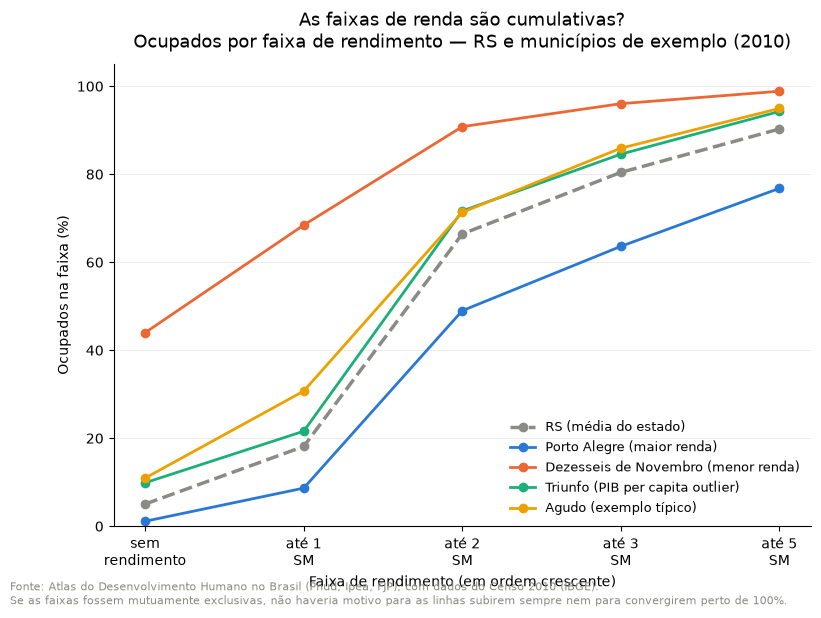

In [ ]:
#análise geral da renda

# Gráfico de verificação — as colunas de faixa de renda são cumulativas?
# Município do RS, Censo 2010 (Atlas do Desenvolvimento Humano no Brasil)
#
# Não é um dos gráficos das perguntas de análise: é um gráfico de checagem,
# pra confirmar visualmente que "% até 1 SM", "% até 2 SM" etc. formam uma
# distribuição acumulada (cada faixa >= a anterior, convergindo perto de 100%)
# e não faixas mutuamente exclusivas.


faixas_cols = [
    "% dos ocupados sem rendimento 2010",
    "% dos ocupados com rendimento de até 1 salário mínimo 2010",
    "% dos ocupados com rendimento de até 2 salários mínimo 2010",
    "% dos ocupados com rendimento de até 3 salários mínimo 2010",
    "% dos ocupados com rendimento de até 5 salários mínimo 2010",
]
for c in faixas_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# rótulos curtos pro eixo x, na ordem certa da faixa
rotulos_faixa = ["sem\nrendimento", "até 1\nSM", "até 2\nSM", "até 3\nSM", "até 5\nSM"]

# ---------------------------------------------------------------
# 2. Seleção das linhas: média do RS (linha já existe agregada no
#    dataset) + municípios de exemplo, escolhidos por contraste
#    (maior renda, menor renda, outlier de PIB per capita, e um
#    município "comum" no meio da distribuição)
# ---------------------------------------------------------------
territorios_exemplo = [
    ("Rio Grande do Sul", "RS (média do estado)"),
    ("Porto Alegre (RS)", "Porto Alegre (maior renda)"),
    ("Dezesseis de Novembro (RS)", "Dezesseis de Novembro (menor renda)"),
    ("Triunfo (RS)", "Triunfo (PIB per capita outlier)"),
    ("Agudo (RS)", "Agudo (exemplo típico)"),
]

serie = {}
for nome_base, rotulo in territorios_exemplo:
    linha = df[df["Territorialidades"] == nome_base]
    if linha.empty:
        print(f"Aviso: '{nome_base}' não encontrado no dataset, pulando.")
        continue
    serie[rotulo] = linha.iloc[0][faixas_cols].values.astype(float)

# ---------------------------------------------------------------
# 3. Gráfico
# ---------------------------------------------------------------
# RS como linha de referência (cinza, tracejada); municípios em cores
# categóricas (ordem fixa, paleta validada para pares adjacentes)
CORES = {
    "RS (média do estado)": "#8a8a86",
    "Porto Alegre (maior renda)": "#2a78d6",
    "Dezesseis de Novembro (menor renda)": "#eb6834",
    "Triunfo (PIB per capita outlier)": "#1baf7a",
    "Agudo (exemplo típico)": "#eda100",
}

fig, ax = plt.subplots(figsize=(9, 6))
x = range(len(rotulos_faixa))

for rotulo, valores in serie.items():
    is_rs = rotulo.startswith("RS")
    ax.plot(
        x,
        valores,
        marker="o",
        markersize=6,
        linewidth=2.5 if is_rs else 2,
        linestyle="--" if is_rs else "-",
        color=CORES[rotulo],
        label=rotulo,
        zorder=3 if is_rs else 2,
    )

ax.set_xticks(list(x))
ax.set_xticklabels(rotulos_faixa)
ax.set_ylim(0, 105)

ax.set_title(
    "As faixas de renda são cumulativas?\nOcupados por faixa de rendimento — RS e municípios de exemplo (2010)",
    fontsize=13,
    pad=12,
)
ax.set_xlabel("Faixa de rendimento (em ordem crescente)")
ax.set_ylabel("Ocupados na faixa (%)")

ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", linestyle="-", linewidth=0.5, color="#e5e5e0", zorder=0)
ax.set_axisbelow(True)

ax.legend(frameon=False, loc="lower right", fontsize=9)

fig.text(
    0.01, -0.02,
    "Fonte: Atlas do Desenvolvimento Humano no Brasil (Pnud, Ipea, FJP), com dados do Censo 2010 (IBGE).\n"
    "Se as faixas fossem mutuamente exclusivas, não haveria motivo para as linhas subirem sempre "
    "nem para convergirem perto de 100%.",
    fontsize=8, color="#8a8a86",
)

# plt.tight_layout()
# plt.savefig("grafico_check_cumulativo_faixas_renda.png", dpi=150, bbox_inches="tight")
plt.show()

Municípios com todos os indicadores preenchidos: 496

Limites dos quartis (%): [np.float64(12.4), np.float64(22.7), np.float64(29.1), np.float64(35.7), np.float64(64.5)]

Municípios por quartil:
quartil_escolaridade
Q1\n(12.4% – 22.7%)    124
Q2\n(22.7% – 29.1%)    125
Q3\n(29.1% – 35.7%)    123
Q4\n(35.7% – 64.5%)    124
dtype: int64

Distribuição média de faixas de renda por quartil (%):
                      Sem rendimento  Mais de 0 até 1 SM  Mais de 1 até 2 SM  \
quartil_escolaridade                                                           
Q1\n(12.4% – 22.7%)             18.2                28.5                36.3   
Q2\n(22.7% – 29.1%)             14.8                21.1                43.0   
Q3\n(29.1% – 35.7%)             10.6                17.4                46.4   
Q4\n(35.7% – 64.5%)              4.8                13.3                50.5   

                      Mais de 2 até 3 SM  Mais de 3 até 5 SM  Mais de 5 SM  
quartil_escolaridade                             

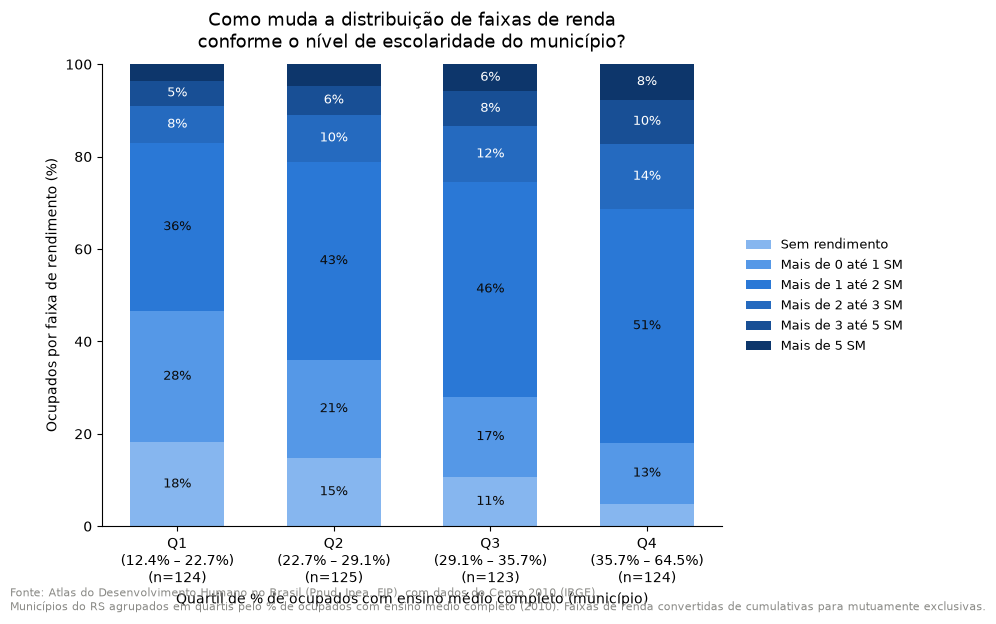

In [5]:
import numpy as np

col_escolaridade = "% dos ocupados com ensino médio completo 2010"
cols_faixas_cumulativas = [
    "% dos ocupados sem rendimento 2010",
    "% dos ocupados com rendimento de até 1 salário mínimo 2010",
    "% dos ocupados com rendimento de até 2 salários mínimo 2010",
    "% dos ocupados com rendimento de até 3 salários mínimo 2010",
    "% dos ocupados com rendimento de até 5 salários mínimo 2010",
]
for c in [col_escolaridade] + cols_faixas_cumulativas:
    municipios[c] = pd.to_numeric(municipios[c], errors="coerce")

municipios = municipios.dropna(subset=[col_escolaridade] + cols_faixas_cumulativas)
print(f"Municípios com todos os indicadores preenchidos: {len(municipios)}")

# ---------------------------------------------------------------
# 2. Conversão das faixas cumulativas em faixas mutuamente exclusivas
#    (checado antes: até_1 >= sem_rendimento, até_2 >= até_1, etc. —
#    são cumulativas, não faixas independentes)
# ---------------------------------------------------------------
nomes_faixas = ["Sem rendimento", "Mais de 0 até 1 SM", "Mais de 1 até 2 SM",
                 "Mais de 2 até 3 SM", "Mais de 3 até 5 SM", "Mais de 5 SM"]
 
# remove as colunas de faixa se a célula for rodada de novo, pra não duplicar
municipios = municipios.drop(columns=nomes_faixas, errors="ignore")

sem_rendimento, ate_1, ate_2, ate_3, ate_5 = [municipios[c] for c in cols_faixas_cumulativas]

faixas_exclusivas = pd.DataFrame({
    "Sem rendimento": sem_rendimento,
    "Mais de 0 até 1 SM": ate_1 - sem_rendimento,
    "Mais de 1 até 2 SM": ate_2 - ate_1,
    "Mais de 2 até 3 SM": ate_3 - ate_2,
    "Mais de 3 até 5 SM": ate_5 - ate_3,
    "Mais de 5 SM": 100 - ate_5,
})

assert (faixas_exclusivas.min() >= -0.01).all(), "faixa negativa encontrada — checar dados"
municipios = pd.concat([municipios, faixas_exclusivas], axis=1)

# ---------------------------------------------------------------
# 3. Agrupamento por QUARTIL de escolaridade (pd.qcut, 4 grupos,
#    mesma quantidade de municípios por grupo). Os rótulos são
#    construídos a partir dos limites reais de cada quartil.
# ---------------------------------------------------------------
municipios["quartil_escolaridade"], limites = pd.qcut(
    municipios[col_escolaridade], 4, retbins=True
)
 
rotulos_quartil = {
    intervalo: f"Q{i+1}\n({limites[i]:.1f}% – {limites[i+1]:.1f}%)"
    for i, intervalo in enumerate(sorted(municipios["quartil_escolaridade"].unique()))
}
municipios["quartil_escolaridade"] = municipios["quartil_escolaridade"].map(rotulos_quartil)
ordem_grupos = list(rotulos_quartil.values())
 
medias_por_quartil = (
    municipios.groupby("quartil_escolaridade", observed=True)[nomes_faixas]
    .mean()
    .reindex(ordem_grupos)
)
contagem_por_quartil = (
    municipios.groupby("quartil_escolaridade", observed=True).size().reindex(ordem_grupos)
)
print("\nLimites dos quartis (%):", [round(b, 1) for b in limites])
print("\nMunicípios por quartil:")
print(contagem_por_quartil)
print("\nDistribuição média de faixas de renda por quartil (%):")
print(medias_por_quartil.round(1))

# ---------------------------------------------------------------
# 4. Gráfico — barras 100% empilhadas, rampa sequencial (1 tom, claro->escuro)
# ---------------------------------------------------------------
CORES_SEQUENCIAIS = ["#86b6ef", "#5598e7", "#2a78d6", "#256abf", "#184f95", "#0d366b"]

fig, ax = plt.subplots(figsize=(8, 6))

grupos = medias_por_quartil.index.tolist()
x = np.arange(len(grupos))
base = np.zeros(len(grupos))

for faixa, cor in zip(nomes_faixas, CORES_SEQUENCIAIS):
    valores = medias_por_quartil[faixa].values
    barras = ax.bar(x, valores, bottom=base, color=cor, width=0.6, label=faixa)

    # rótulo direto só nos segmentos grandes o bastante pra caber o texto
    for i, v in enumerate(valores):
        if v >= 5:
            ax.text(
                x[i], base[i] + v / 2, f"{v:.0f}%",
                ha="center", va="center", fontsize=9,
                color="white" if faixa in ("Mais de 2 até 3 SM", "Mais de 3 até 5 SM", "Mais de 5 SM") else "#0b0b0b",
            )
    base += valores

ax.set_xticks(x)
ax.set_xticklabels([f"{g}\n(n={contagem_por_quartil[g]})" for g in grupos])
ax.set_ylim(0, 100)

ax.set_title(
    "Como muda a distribuição de faixas de renda\nconforme o nível de escolaridade do município?",
    fontsize=13, pad=12,
)
ax.set_xlabel("Quartil de % de ocupados com ensino médio completo (município)")
ax.set_ylabel("Ocupados por faixa de rendimento (%)")

ax.spines[["top", "right"]].set_visible(False)
ax.set_axisbelow(True)

# legenda na ordem das faixas (baixa -> alta renda), fora da área do gráfico
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, frameon=False, loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=9)

fig.text(
    0.01, -0.03,
    "Fonte: Atlas do Desenvolvimento Humano no Brasil (Pnud, Ipea, FJP), com dados do Censo 2010 (IBGE).\n"
    "Municípios do RS agrupados em quartis pelo % de ocupados com ensino médio completo (2010). "
    "Faixas de renda convertidas de cumulativas para mutuamente exclusivas.",
    fontsize=8, color="#8a8a86",
)

# plt.tight_layout()
# plt.savefig("grafico2.1_faixas_renda_x_escolaridade_quartil.png", dpi=150, bbox_inches="tight")
plt.show()


Limites das faixas (%): [np.float64(12.4), np.float64(29.8), np.float64(47.2), np.float64(64.5)]

Municípios por faixa de escolaridade:
faixa_escolaridade
Baixa escolaridade    265
Média escolaridade    210
Alta escolaridade      21
dtype: int64

Distribuição média de faixas de renda por faixa de escolaridade (%):
                    Sem rendimento  Mais de 0 até 1 SM  Mais de 1 até 2 SM  \
faixa_escolaridade                                                           
Baixa escolaridade            16.2                24.4                40.1   
Média escolaridade             8.0                15.7                48.5   
Alta escolaridade              2.0                 9.9                49.5   

                    Mais de 2 até 3 SM  Mais de 3 até 5 SM  Mais de 5 SM  
faixa_escolaridade                                                        
Baixa escolaridade                 9.3                 5.9           4.2  
Média escolaridade                13.0                 8.4         

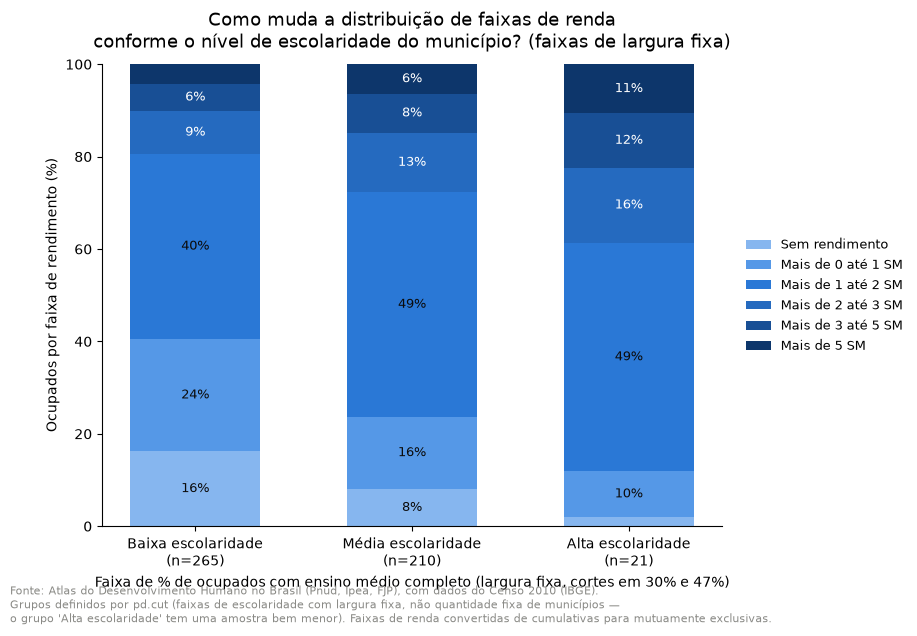

In [6]:
# Gráfico 2.2 (versão com pd.cut) — Como muda a distribuição de faixas de
# renda conforme o nível de escolaridade do município?
# Municípios do Rio Grande do Sul, Censo 2010 (Atlas do Desenvolvimento Humano no Brasil)
#
# Diferença em relação à primeira versão: em vez de pd.qcut (3 grupos com a
# MESMA QUANTIDADE de municípios cada), aqui os grupos são definidos por
# pd.cut (3 faixas de escolaridade com a MESMA LARGURA em pontos percentuais,
# de 12,36% até 64,53%). Isso muda bastante o tamanho de cada grupo — ver
# comentário abaixo, na seção 3.



# ---------------------------------------------------------------
# 3. Agrupamento por faixa de escolaridade — pd.cut (largura fixa),
#    não pd.qcut (quantidade fixa). Os 3 grupos ficam com o MESMO
#    intervalo de pontos percentuais, mas NÃO com a mesma quantidade
#    de municípios: como a maioria dos municípios do RS está
#    concentrada na faixa baixa/média de escolaridade, o grupo "alta"
#    acaba com poucos municípios — vale checar o n de cada grupo antes
#    de interpretar o gráfico.
# ---------------------------------------------------------------
municipios["faixa_escolaridade"], limites = pd.cut(
    municipios[col_escolaridade], 3,
    labels=["Baixa escolaridade", "Média escolaridade", "Alta escolaridade"],
    retbins=True,
)
print("\nLimites das faixas (%):", [round(b, 1) for b in limites])

nomes_faixas = list(faixas_exclusivas.columns)
medias_por_faixa = municipios.groupby("faixa_escolaridade", observed=True)[nomes_faixas].mean()
contagem_por_faixa = municipios.groupby("faixa_escolaridade", observed=True).size()
print("\nMunicípios por faixa de escolaridade:")
print(contagem_por_faixa)
print("\nDistribuição média de faixas de renda por faixa de escolaridade (%):")
print(medias_por_faixa.round(1))

# ---------------------------------------------------------------
# 4. Gráfico — barras 100% empilhadas, rampa sequencial (1 tom, claro->escuro)
# ---------------------------------------------------------------
CORES_SEQUENCIAIS = ["#86b6ef", "#5598e7", "#2a78d6", "#256abf", "#184f95", "#0d366b"]

fig, ax = plt.subplots(figsize=(8, 6))

grupos = medias_por_faixa.index.tolist()
x = np.arange(len(grupos))
base = np.zeros(len(grupos))

for faixa, cor in zip(nomes_faixas, CORES_SEQUENCIAIS):
    valores = medias_por_faixa[faixa].values
    ax.bar(x, valores, bottom=base, color=cor, width=0.6, label=faixa)

    for i, v in enumerate(valores):
        if v >= 5:
            ax.text(
                x[i], base[i] + v / 2, f"{v:.0f}%",
                ha="center", va="center", fontsize=9,
                color="white" if faixa in ("Mais de 2 até 3 SM", "Mais de 3 até 5 SM", "Mais de 5 SM") else "#0b0b0b",
            )
    base += valores

ax.set_xticks(x)
ax.set_xticklabels([f"{g}\n(n={contagem_por_faixa[g]})" for g in grupos])
ax.set_ylim(0, 100)

ax.set_title(
    "Como muda a distribuição de faixas de renda\nconforme o nível de escolaridade do município? (faixas de largura fixa)",
    fontsize=13, pad=12,
)
ax.set_xlabel(f"Faixa de % de ocupados com ensino médio completo (largura fixa, cortes em {limites[1]:.0f}% e {limites[2]:.0f}%)")
ax.set_ylabel("Ocupados por faixa de rendimento (%)")

ax.spines[["top", "right"]].set_visible(False)
ax.set_axisbelow(True)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, frameon=False, loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=9)

fig.text(
    0.01, -0.05,
    "Fonte: Atlas do Desenvolvimento Humano no Brasil (Pnud, Ipea, FJP), com dados do Censo 2010 (IBGE).\n"
    "Grupos definidos por pd.cut (faixas de escolaridade com largura fixa, não quantidade fixa de municípios — \n"
    "o grupo 'Alta escolaridade' tem uma amostra bem menor). Faixas de renda convertidas de cumulativas para mutuamente exclusivas.",
    fontsize=8, color="#8a8a86",
)

# plt.tight_layout()
# plt.savefig("grafico2.2_faixas_renda_x_escolaridade_tercil.png", dpi=150, bbox_inches="tight")
plt.show()

## Pergunta 3

O PIB per capita reflete a escolaridade e a renda dos trabalhadores?

### 3.0 — Preparação dos dados e estatísticas de apoio

O bloco abaixo remonta o recorte a partir de `df`, em vez de reaproveitar a variável `municipios`, porque as células das perguntas 1 e 2 modificam esse DataFrame (filtram linhas e acrescentam colunas de faixa de renda). Assim esta seção roda igual independentemente da ordem em que as anteriores foram executadas.

Duas decisões de tratamento:

- **PIB per capita** entra como a **média de 2013 a 2016**, e não como um ano isolado. Os quatro anos são altamente correlacionados entre si (r ≥ 0,92), então a média reduz o ruído de um ano atípico sem mudar o ordenamento dos municípios.
- A distribuição do PIB per capita é **fortemente assimétrica à direita** (assimetria ≈ 5): a mediana é R$ 19 mil/hab. e o máximo passa de R$ 177 mil/hab. Por isso os gráficos usam **escala logarítmica** no eixo do PIB, e reportamos também o **Spearman**, que depende só da ordem dos municípios e não é dominado pelos extremos.

In [ ]:
# ---------------------------------------------------------------
# Pergunta 3 — preparacao dos dados e estatisticas de apoio
# ---------------------------------------------------------------
import numpy as np

col_escolaridade = "% dos ocupados com ensino médio completo 2010"
col_renda = "Rendimento médio dos ocupados 2010"
cols_pib = [f"Produto Interno Bruto per capita {ano}" for ano in (2013, 2014, 2015, 2016)]

p3 = df[~df["Territorialidades"].isin(["Brasil", "Rio Grande do Sul"])].copy()
for c in [col_escolaridade, col_renda] + cols_pib:
    p3[c] = pd.to_numeric(p3[c], errors="coerce")

p3["pib_pc_medio"] = p3[cols_pib].mean(axis=1)
p3 = p3.dropna(subset=[col_escolaridade, col_renda, "pib_pc_medio"])
print(f"Municípios com escolaridade, renda e PIB preenchidos: {len(p3)}")

print("\nCorrelação entre os anos de PIB per capita (2013-2016):")
print(p3[cols_pib].corr().round(3).to_string())

print(f"\nAssimetria do PIB per capita médio: {p3['pib_pc_medio'].skew():.2f}")
print("Quantis do PIB per capita (R$ mil/hab.):")
print(p3["pib_pc_medio"].quantile([0.05, 0.25, 0.50, 0.75, 0.95, 1.00]).round(1).to_string())

def resumo_associacao(nome, x, y):
    # Pearson em nivel e em log10: o PIB per capita e muito assimetrico, entao
    # o coeficiente em nivel fica dominado por poucos municipios extremos.
    # Spearman entra como versao robusta, baseada so na ordem dos municipios.
    r_lin, _ = stats.pearsonr(x, y)
    r_log, _ = stats.pearsonr(np.log10(x), y)
    rho, _ = stats.spearmanr(x, y)
    print(f"{nome:34s} Pearson={r_lin:+.3f}  Pearson(log10 PIB)={r_log:+.3f}"
          f"  Spearman={rho:+.3f}  R²(log)={r_log ** 2:.3f}")

print("\nAssociação com o PIB per capita:")
resumo_associacao("PIB x escolaridade", p3["pib_pc_medio"], p3[col_escolaridade])
resumo_associacao("PIB x rendimento", p3["pib_pc_medio"], p3[col_renda])
r_esc_renda, _ = stats.pearsonr(p3[col_escolaridade], p3[col_renda])
print(f"\nReferência (gráfico 1) escolaridade x rendimento: Pearson={r_esc_renda:+.3f}"
      f"  R²={r_esc_renda**2:.3f}")

p3["quintil_pib"] = pd.qcut(p3["pib_pc_medio"], 5, labels=[f"Q{i}" for i in range(1, 6)])
resumo_quintis = p3.groupby("quintil_pib", observed=True).agg(
    n=("pib_pc_medio", "size"),
    pib_mediano=("pib_pc_medio", "median"),
    renda_mediana=(col_renda, "median"),
    renda_p10=(col_renda, lambda s: s.quantile(0.10)),
    renda_p90=(col_renda, lambda s: s.quantile(0.90)),
    escolaridade_mediana=(col_escolaridade, "median"),
)
print("\nMedianas por quintil de PIB per capita:")
print(resumo_quintis.round(1).to_string())

### Gráfico 3.1 — A relação entre PIB per capita, escolaridade e rendimento

Dispersão de cada município do RS. O eixo do PIB está em escala log, e a reta de tendência foi ajustada em `log10(PIB)`.

In [ ]:
# ---------------------------------------------------------------
# Grafico 3.1 - dispersao PIB per capita x escolaridade e x rendimento
# ---------------------------------------------------------------
COR_PONTOS = "#2a78d6"
COR_LINHA = "#52514e"
COR_DESTAQUE = "#eb6834"

# municipios comentados no texto: os extremos que mostram o descolamento
# entre PIB e renda, e dois casos de PIB baixo com renda/escolaridade altas.
# Os deslocamentos do rotulo (dx, dy, em pontos) sao por painel, so pra
# evitar que o texto caia em cima de outro ponto ou da anotacao do R².
destaques = {
    "Triunfo (RS)":         ("Triunfo",         (-46, 12), (-46, 14)),
    "Pinhal da Serra (RS)": ("Pinhal da Serra", (-34, -20), (-34, -20)),
    "Capão do Cipó (RS)":   ("Capão do Cipó",   (-36, -20), (-36, -20)),
    "Porto Alegre (RS)":    ("Porto Alegre",    (11, -3), (-74, -4)),
    "Santa Maria (RS)":     ("Santa Maria",     (-24, 11), (-26, 11)),
}

paineis = [
    (col_escolaridade, "Ocupados com ensino médio completo (%)",
     "PIB per capita x escolaridade"),
    (col_renda, "Rendimento médio dos ocupados (R$, 2010)",
     "PIB per capita x rendimento"),
]

fig, axes = plt.subplots(1, 2, figsize=(13, 5.6))

for i_painel, (ax, (col_y, rotulo_y, titulo_painel)) in enumerate(zip(axes, paineis)):
    x = p3["pib_pc_medio"]
    y = p3[col_y]

    # regressao ajustada em log10(PIB): a variavel e fortemente assimetrica
    # (assimetria ~5), entao a relacao e aproximadamente log-linear e o eixo
    # x usa escala logaritmica. Ajustar em nivel deixaria a reta refem dos
    # poucos municipios de PIB altissimo.
    slope, intercept, r, p_valor, erro = stats.linregress(np.log10(x), y)
    x_linha = np.logspace(np.log10(x.min()), np.log10(x.max()), 100)
    y_linha = slope * np.log10(x_linha) + intercept
    rho, _ = stats.spearmanr(x, y)

    ax.scatter(x, y, s=20, color=COR_PONTOS, alpha=0.5, edgecolors="none",
               zorder=2, label=f"Municípios do RS (n={len(p3)})")
    ax.plot(x_linha, y_linha, color=COR_LINHA, linewidth=2, linestyle="--",
            zorder=3, label="Tendência (ajuste em log do PIB)")

    for nome, (rotulo, *deslocamentos) in destaques.items():
        linha = p3[p3["Territorialidades"] == nome]
        if linha.empty:
            continue
        ax.scatter(linha["pib_pc_medio"], linha[col_y], s=46, color=COR_DESTAQUE,
                   edgecolors="white", linewidth=0.8, zorder=4)
        ax.annotate(rotulo,
                    xy=(linha["pib_pc_medio"].iloc[0], linha[col_y].iloc[0]),
                    xytext=deslocamentos[i_painel], textcoords="offset points",
                    fontsize=8.5, color=COR_DESTAQUE, zorder=5)

    ax.set_xscale("log")
    ax.set_xticks([10, 20, 30, 50, 100, 180])
    ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
    ax.set_xlabel("PIB per capita — média 2013-2016 (R$ mil por habitante, escala log)")
    ax.set_ylabel(rotulo_y)
    # as estatisticas vao no titulo do painel, e nao dentro da area de
    # plotagem: com 496 pontos qualquer caixa de texto interna acaba caindo
    # em cima de algum municipio.
    ax.set_title(
        f"{titulo_painel}\n"
        f"R² = {r ** 2:.2f}  ·  r = {r:.2f}  ·  Spearman = {rho:.2f}",
        fontsize=11, pad=8,
    )

    # folga no topo pra caber o rotulo do municipio mais alto do painel
    ax.set_ylim(top=ax.get_ylim()[1] + 0.06 * (y.max() - y.min()))

    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", linestyle="-", linewidth=0.5, color="#e5e5e0", zorder=0)
    ax.set_axisbelow(True)

axes[0].legend(frameon=False, loc="upper left", fontsize=9)

fig.suptitle(
    "O PIB per capita reflete a escolaridade e a renda dos trabalhadores?",
    fontsize=14, y=1.01,
)
fig.text(
    0.5, 0.955,
    "Para comparação, escolaridade x rendimento entre si (gráfico 1) tem "
    f"R² = {r_esc_renda**2:.2f} — bem acima dos dois painéis abaixo.",
    fontsize=9.5, color="#8a8a86", ha="center",
)

fig.text(
    0.01, -0.06,
    "Fonte: Atlas do Desenvolvimento Humano no Brasil (Pnud, Ipea, FJP). Escolaridade e rendimento: Censo 2010 (IBGE); "
    "PIB per capita: média de 2013 a 2016, a preços constantes.\n"
    "Defasagem temporal entre as variáveis (2010 x 2013-2016) — a leitura é de posição relativa entre municípios, não de causalidade. "
    "Em destaque, casos comentados no texto.",
    fontsize=8, color="#8a8a86",
)

plt.tight_layout()
# plt.savefig("grafico3.1_pib_x_escolaridade_e_renda.png", dpi=150, bbox_inches="tight")
plt.show()


### Gráfico 3.2 — Quanto o PIB per capita ajuda a prever renda e escolaridade?

O gráfico anterior mede a força da associação no conjunto. Este responde à versão prática da pergunta: sabendo apenas o quintil de PIB do município, quão bem conseguimos antecipar a renda e a escolaridade dos ocupados? O boxplot separa a **tendência** (mediana) da **dispersão dentro do grupo** (caixa e bigodes).

In [ ]:
# ---------------------------------------------------------------
# Grafico 3.2 - distribuicao de renda e escolaridade por quintil de PIB
# ---------------------------------------------------------------
# O grafico 3.1 mostra que existe tendencia positiva, mas fraca. Este
# grafico responde a pergunta seguinte: se eu souber so o quintil de PIB do
# municipio, quanto isso me diz sobre a renda dos ocupados? O boxplot mostra
# a MEDIANA (a tendencia) e a CAIXA/BIGODES (a dispersao dentro do grupo).
# Se as caixas se sobrepoem muito, o PIB nao serve como substituto.

COR_CAIXA = "#2a78d6"
COR_LINHA = "#52514e"
COR_MEDIANA = "#eb6834"

paineis_box = [
    (col_renda, "Rendimento médio dos ocupados (R$, 2010)", "Rendimento dos ocupados"),
    (col_escolaridade, "Ocupados com ensino médio completo (%)", "Escolaridade dos ocupados"),
]

ordem_quintis = [f"Q{i}" for i in range(1, 6)]
rotulos_quintis = [
    f"{q}\nR$ {resumo_quintis.loc[q, 'pib_mediano']:.0f} mil\nn={resumo_quintis.loc[q, 'n']}"
    for q in ordem_quintis
]

fig, axes = plt.subplots(1, 2, figsize=(13, 5.6))

for ax, (col_y, rotulo_y, titulo_painel) in zip(axes, paineis_box):
    grupos = [p3.loc[p3["quintil_pib"] == q, col_y].values for q in ordem_quintis]

    bp = ax.boxplot(
        grupos, patch_artist=True, widths=0.55, showfliers=True,
        medianprops=dict(color=COR_MEDIANA, linewidth=2),
        boxprops=dict(facecolor="#d8e7f9", edgecolor=COR_CAIXA, linewidth=1.2),
        whiskerprops=dict(color=COR_CAIXA, linewidth=1.2),
        capprops=dict(color=COR_CAIXA, linewidth=1.2),
        flierprops=dict(marker="o", markersize=3, markerfacecolor=COR_CAIXA,
                        markeredgecolor="none", alpha=0.45),
    )

    # linha ligando as medianas: deixa explicito que a inclinacao e pequena
    medianas = [np.median(g) for g in grupos]
    ax.plot(range(1, 6), medianas, color=COR_MEDIANA, linewidth=1.5,
            linestyle="--", marker="o", markersize=4, zorder=4,
            label="Mediana do grupo")

    ax.set_xticks(range(1, 6))
    ax.set_xticklabels(rotulos_quintis, fontsize=8.5)
    ax.set_xlabel("Quintil de PIB per capita do município (média 2013-2016)\n"
                  "R$ = PIB per capita mediano do quintil")
    ax.set_ylabel(rotulo_y)

    variacao = (medianas[-1] / medianas[0] - 1) * 100
    ax.set_title(
        f"{titulo_painel}\nMediana do Q1 ao Q5: {variacao:+.0f}%",
        fontsize=11, pad=8,
    )

    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", linestyle="-", linewidth=0.5, color="#e5e5e0", zorder=0)
    ax.set_axisbelow(True)

axes[0].legend(frameon=False, loc="upper left", fontsize=9)

fig.suptitle(
    "Saber o PIB per capita do município é suficiente para prever a renda e a escolaridade?",
    fontsize=14, y=1.01,
)

fig.text(
    0.01, -0.07,
    "Fonte: Atlas do Desenvolvimento Humano no Brasil (Pnud, Ipea, FJP). Escolaridade e rendimento: Censo 2010 (IBGE); "
    "PIB per capita: média de 2013 a 2016, a preços constantes.\n"
    "Caixa = 1º ao 3º quartil do grupo; linha laranja = mediana; bigodes = 1,5 x intervalo interquartil; pontos = municípios fora dessa faixa.\n"
    "As medianas sobem pouco e as caixas se sobrepõem em quase toda a extensão: o quintil de PIB separa mal os municípios.",
    fontsize=8, color="#8a8a86",
)

plt.tight_layout()
# plt.savefig("grafico3.2_renda_escolaridade_por_quintil_de_pib.png", dpi=150, bbox_inches="tight")
plt.show()


### Gráfico 3.3 — Os municípios de maior PIB per capita estão no topo da renda?

Do agregado para o caso concreto: entre os 15 municípios com maior PIB per capita do RS, em que posição cada um aparece quando ordenamos os 496 municípios por rendimento e por escolaridade dos ocupados.

In [ ]:
# ---------------------------------------------------------------
# Grafico 3.3 - os municipios mais ricos em PIB estao no topo da renda?
# ---------------------------------------------------------------
# Os graficos anteriores mostram a relacao no agregado. Este mostra o caso
# concreto: pegando os 15 municipios com maior PIB per capita do RS, em que
# posicao eles aparecem quando a gente ordena por rendimento e por
# escolaridade dos ocupados? Se o PIB "refletisse" essas variaveis, os tres
# marcadores de cada linha ficariam proximos, todos na esquerda do eixo.

N_TOPO = 15
COR_PIB = "#2a78d6"
COR_RENDA = "#eb6834"
COR_ESCOLARIDADE = "#1baf7a"

# posicao 1 = melhor colocado entre os 496 municipios
ranking = p3.copy()
ranking["pos_pib"] = ranking["pib_pc_medio"].rank(ascending=False, method="min").astype(int)
ranking["pos_renda"] = ranking[col_renda].rank(ascending=False, method="min").astype(int)
ranking["pos_escolaridade"] = ranking[col_escolaridade].rank(ascending=False, method="min").astype(int)

topo = ranking.nsmallest(N_TOPO, "pos_pib").sort_values("pos_pib", ascending=False)
n_municipios = len(ranking)

print(f"Posição no ranking de rendimento dos {N_TOPO} municípios de maior PIB per capita "
      f"(de {n_municipios} municípios):")
print(topo.sort_values("pos_pib")[
    ["Territorialidades", "pib_pc_medio", col_renda, "pos_pib", "pos_renda", "pos_escolaridade"]
].to_string(index=False, float_format=lambda v: f"{v:.1f}"))
print(f"\nPosição mediana em rendimento: {int(topo['pos_renda'].median())}º de {n_municipios}")
print(f"Posição mediana em escolaridade: {int(topo['pos_escolaridade'].median())}º de {n_municipios}")

fig, ax = plt.subplots(figsize=(10.5, 7))

y = np.arange(len(topo))

for i, (_, linha) in enumerate(topo.iterrows()):
    posicoes = [linha["pos_pib"], linha["pos_renda"], linha["pos_escolaridade"]]
    # a linha cinza liga a melhor e a pior colocacao do municipio: quanto
    # mais longa, maior o descolamento entre producao e indicadores das pessoas
    ax.plot([min(posicoes), max(posicoes)], [i, i],
            color="#cfcfca", linewidth=1.6, zorder=1)

ax.scatter(topo["pos_escolaridade"], y, s=58, color=COR_ESCOLARIDADE, zorder=3,
           edgecolors="white", linewidth=0.8, label="Posição em escolaridade")
ax.scatter(topo["pos_renda"], y, s=58, color=COR_RENDA, zorder=3,
           edgecolors="white", linewidth=0.8, label="Posição em rendimento")
ax.scatter(topo["pos_pib"], y, s=58, color=COR_PIB, zorder=4,
           edgecolors="white", linewidth=0.8, label="Posição em PIB per capita")

ax.set_yticks(y)
ax.set_yticklabels(
    [f"{t.replace(' (RS)', '')}  (R$ {p:.0f} mil)"
     for t, p in zip(topo["Territorialidades"], topo["pib_pc_medio"])],
    fontsize=9,
)
ax.set_xlim(0, n_municipios + 10)
ax.set_xlabel(f"Posição no ranking entre os {n_municipios} municípios do RS "
              "(1º = melhor; mais à direita = pior)")

# mediana do ranking: referencia visual pro "municipio do meio"
ax.axvline(n_municipios / 2, color="#8a8a86", linestyle=":", linewidth=1.2, zorder=0)
ax.annotate("mediana do estado", xy=(n_municipios / 2, len(topo) - 0.4),
            xytext=(6, 0), textcoords="offset points",
            fontsize=8.5, color="#8a8a86", va="center")

ax.set_title(
    f"Os {N_TOPO} municípios de maior PIB per capita do RS\n"
    "não são os que têm maior rendimento nem maior escolaridade",
    fontsize=13, pad=12,
)

ax.spines[["top", "right", "left"]].set_visible(False)
ax.tick_params(axis="y", length=0)
ax.grid(axis="x", linestyle="-", linewidth=0.5, color="#e5e5e0", zorder=0)
ax.set_axisbelow(True)

ax.legend(frameon=False, loc="lower center", bbox_to_anchor=(0.5, -0.20),
          ncol=3, fontsize=9)

fig.text(
    0.01, -0.07,
    "Fonte: Atlas do Desenvolvimento Humano no Brasil (Pnud, Ipea, FJP). Escolaridade e rendimento: Censo 2010 (IBGE); "
    "PIB per capita: média de 2013 a 2016, a preços constantes.\n"
    "Entre parênteses, o PIB per capita médio do município. O PIB per capita mede a produção dentro do município, "
    "e não a renda de quem mora nele: em municípios pequenos\ncom uma grande planta industrial ou agropecuária, "
    "o denominador populacional é baixo e o valor produzido não fica com os residentes.",
    fontsize=8, color="#8a8a86",
)

plt.tight_layout()
# plt.savefig("grafico3.3_ranking_pib_x_renda_escolaridade.png", dpi=150, bbox_inches="tight")
plt.show()


### Interpretação

**Resposta curta: não — ou só muito parcialmente.** O PIB per capita municipal é um indicador fraco da escolaridade e da renda de quem vive no município.

**O que os números mostram**

| Par de variáveis | Pearson (log PIB) | Spearman | R² |
|---|---|---|---|
| PIB per capita × escolaridade | +0,33 | +0,37 | 0,11 |
| PIB per capita × rendimento | +0,44 | +0,49 | 0,19 |
| Escolaridade × rendimento (gráfico 1) | +0,70 | — | 0,49 |

A associação existe e é positiva, mas o PIB explica cerca de **11% da variação da escolaridade** e **19% da do rendimento**. Escolaridade e rendimento, entre si, compartilham **49%**. Ou seja: as duas variáveis que descrevem *as pessoas* andam juntas; a variável que descreve *a produção* se descola das duas.

**Por que isso acontece (o ponto central da pergunta)**

O PIB per capita mede o valor produzido **dentro** do território, dividido pela população **residente**. São dois recortes diferentes. Em municípios pequenos com uma grande planta industrial ou agropecuária, o numerador é enorme e o denominador é pequeno — mas o valor gerado não fica com os moradores: sai como lucro, tributo, salário de trabalhador que mora em outra cidade ou insumo comprado fora.

Os casos extremos deixam isso explícito:

- **Triunfo** — maior PIB per capita do RS (R$ 178 mil/hab., ~9× a mediana estadual), sede do polo petroquímico. Fica em **205º de 496** em rendimento e **142º** em escolaridade.
- **Pinhal da Serra** — 2º maior PIB (R$ 108 mil/hab.), mas **406º** em rendimento.
- **Capão do Cipó** — 10º maior PIB (R$ 55 mil/hab.) e **455º** em rendimento, quase no fim da fila.
- No sentido oposto, **Santa Maria** tem PIB per capita **abaixo da mediana** (305º) e mesmo assim é **10º** em rendimento e **6º** em escolaridade — economia de serviços, universidade e administração pública, que empregam bem sem gerar PIB alto por habitante.

Dos 15 municípios de maior PIB per capita, a **posição mediana em rendimento é 157º** e em **escolaridade, 202º** — ou seja, o grupo "mais rico" em produção fica, em média, no meio da tabela naquilo que descreve seus moradores.

**O gradiente que de fato existe**

O gráfico 3.2 mostra que a tendência não é nula: do 1º ao 5º quintil de PIB, a mediana do rendimento sobe **+51%** e a da escolaridade **+53%**. Mas duas coisas enfraquecem essa leitura. Primeira: as caixas se sobrepõem em quase toda a extensão — há municípios do Q1 com renda acima de muitos do Q5. Segunda: a **dispersão cresce junto com o PIB** (desvio-padrão do rendimento vai de R$ 182 no Q1 para R$ 314 no Q5; amplitude interquartil, de R$ 248 para R$ 390). Ou seja, o quintil mais alto de PIB é justamente o mais heterogêneo em renda — é onde se misturam municípios-planta e municípios genuinamente prósperos.

*Nota metodológica:* a mediana do Q5 aparece R$ 20 abaixo da do Q4 no gráfico, mas essa diferença **não é distinguível de zero** (IC95 por bootstrap: [-105, +135]). Não deve ser lida como queda real — o achado robusto é o aumento da dispersão, não a inversão entre Q4 e Q5.

**Limitações desta análise**

- **Defasagem temporal:** escolaridade e rendimento são do Censo 2010; o PIB é de 2013–2016. A leitura vale como posição relativa entre municípios, não como relação causal nem como série temporal.
- **Sem dado de população** na base, não é possível ponderar os municípios pelo número de habitantes nem dimensionar o efeito do denominador pequeno — que é exatamente o mecanismo suspeito. Uma versão futura ganharia bastante juntando a população municipal do IBGE.
- **Sem dado de deslocamento pendular** (onde a pessoa mora × onde trabalha), a explicação de "o valor sai do município" fica plausível, mas não verificada com estes dados. As perguntas 6 e 8 atacam esse ponto.

**Implicação para a ferramenta de visualização**

Esse resultado é um argumento direto contra usar PIB per capita como indicador-resumo de bem-estar municipal em um painel. Se a ferramenta exibir PIB per capita, vale exibir ao lado a posição do município em renda e escolaridade — como no gráfico 3.3 — para que a divergência fique visível em vez de escondida atrás de um único número.

## Pergunta 4

A proximidade da capital explica o rendimento médio dos ocupados, ou há regiões não metropolitanas com rendimento equivalente ou superior?

### 4.0 — Preparação: cruzamento com as Regiões Funcionais

**Leia esta seção antes dos gráficos — o recorte muda o que as conclusões significam.**

O arquivo `municipios_regioes_funcionais_rs.csv` mapeia **COREDE → Região Funcional** (27 COREDEs em 9 RFs) e lista, em cada linha, apenas os *principais municípios* daquele COREDE. Isso dá **84 municípios dos 496 do estado (17%)** — e esses 84 não são uma amostra aleatória: são os **polos** de cada região (Porto Alegre, Caxias do Sul, Pelotas, Passo Fundo...).

Consequência direta: a unidade de análise desta seção é o **polo regional**, não o município gaúcho. Todos os títulos e rodapés dizem isso. A pergunta que os gráficos respondem é "*os polos metropolitanos se destacam dos polos das outras regiões?*" — e não "*a região metropolitana tem renda maior que o interior?*", que exigiria os 496.

**Três problemas de dados resolvidos no código:**

| Problema | Ocorrência | Tratamento |
|---|---|---|
| Grafia divergente entre as bases | `Santana do Livramento` → `Sant'Ana do Livramento`; `Restinga Sêca` → `Restinga Seca` | Renomeado antes do merge |
| Município citado em 2 COREDEs, um marcado `(parcial)` | Bagé (Campanha RF3 / Sudoeste RF4) | A linha `(parcial)` não vale como atribuição primária → Bagé fica na RF3 |
| Município citado em 2 COREDEs de **RFs diferentes**, sem desempate | Frederico Westphalen (RF7 / RF9) | **Excluído** — o arquivo não permite decidir |

Vacaria aparece em dois COREDEs (Serra e Campos de Cima da Serra), mas ambos na RF8: não há conflito no nível analisado. Após o tratamento, **84 polos com RF definida, todos encontrados no Atlas**.

In [ ]:
# ---------------------------------------------------------------
# Pergunta 4 — preparacao: cruzamento com as Regioes Funcionais do RS
# ---------------------------------------------------------------
# ATENCAO AO RECORTE: o arquivo municipios_regioes_funcionais_rs.csv mapeia
# COREDE -> Regiao Funcional e lista apenas os PRINCIPAIS municipios de cada
# COREDE (84 de 496). Esses 84 sao os POLOS regionais. Entao a unidade de
# analise desta secao NAO e "municipio do RS", e sim "polo regional" — e a
# leitura tem que ser feita nesses termos. Ver a secao de limitacoes.
import numpy as np
import re

col_renda = "Rendimento médio dos ocupados 2010"

# URL definida na seção 0. encoding="utf-8-sig" remove o BOM que o
# arquivo traz no início da primeira coluna.
regioes = pd.read_csv(URL_REGIOES_FUNCIONAIS, encoding="utf-8-sig")
print(f"Arquivo de regiões: {len(regioes)} COREDEs em "
      f"{regioes['Regiao_Funcional_ID'].nunique()} Regiões Funcionais")

# ---------------------------------------------------------------
# 1. "Explode" a coluna de exemplos: uma linha por municipio citado
# ---------------------------------------------------------------
linhas = []
for _, r in regioes.iterrows():
    for exemplo in r["Principais_Municipios_Exemplos"].split(","):
        nome = exemplo.strip()
        linhas.append({
            "municipio": re.sub(r"\(parcial\)", "", nome).strip(),
            "corede": r["COREDE"],
            "rf": int(r["Regiao_Funcional_ID"]),
            # "(parcial)" marca uma mencao secundaria, nao a atribuicao principal
            "parcial": "(parcial)" in nome,
        })
polos = pd.DataFrame(linhas)

# grafia diferente entre as duas bases
polos["municipio"] = polos["municipio"].replace({
    "Santana do Livramento": "Sant'Ana do Livramento",
    "Restinga Sêca": "Restinga Seca",
})

# ---------------------------------------------------------------
# 2. Resolucao de ambiguidades (o arquivo cita 3 municipios em 2 COREDEs)
#    Regra 1: linha marcada "(parcial)" nao vale como atribuicao primaria.
#             -> resolve Bage (Campanha RF3, e nao Sudoeste RF4).
#    Regra 2: se AINDA restar mais de uma RF para o mesmo municipio, ele e
#             excluido, porque o arquivo nao permite decidir.
#             -> exclui Frederico Westphalen (RF7 x RF9).
#    Vacaria aparece em 2 COREDEs, mas ambos na RF8: sem conflito de RF.
# ---------------------------------------------------------------
polos = polos[~polos["parcial"]]
rf_por_municipio = polos.groupby("municipio")["rf"].nunique()
ambiguos = rf_por_municipio[rf_por_municipio > 1].index.tolist()
if ambiguos:
    print(f"Excluídos por Região Funcional ambígua no arquivo: {ambiguos}")
polos = polos[~polos["municipio"].isin(ambiguos)].drop_duplicates("municipio")

# ---------------------------------------------------------------
# 3. Junta com os indicadores do Atlas
# ---------------------------------------------------------------
base = df[~df["Territorialidades"].isin(["Brasil", "Rio Grande do Sul"])].copy()
base[col_renda] = pd.to_numeric(base[col_renda], errors="coerce")
base["nome"] = base["Territorialidades"].str.replace(" (RS)", "", regex=False)

p4 = base.merge(polos, left_on="nome", right_on="municipio", how="inner")
p4 = p4.dropna(subset=[col_renda])

nao_encontrados = set(polos["municipio"]) - set(p4["nome"])
print(f"Polos com RF definida: {len(polos)} | casaram com o Atlas: {len(p4)}")
if nao_encontrados:
    print(f"Não encontrados no Atlas: {sorted(nao_encontrados)}")

NOMES_RF = {
    1: "RF1 · Metropolitana",
    2: "RF2 · Vales (Pardo/Taquari)",
    3: "RF3 · Sul e Litoral",
    4: "RF4 · Fronteira Oeste",
    5: "RF5 · Central",
    6: "RF6 · Noroeste/Missões",
    7: "RF7 · Produção",
    8: "RF8 · Serra",
    9: "RF9 · Norte",
}
p4["rf_nome"] = p4["rf"].map(NOMES_RF)
p4["grupo_metro"] = np.where(p4["rf"] == 1, "Metropolitana (RF1)", "Demais regiões")

# ---------------------------------------------------------------
# 4. Estatisticas de apoio
# ---------------------------------------------------------------
resumo_rf = (
    p4.groupby("rf_nome")
    .agg(n=(col_renda, "size"), mediana=(col_renda, "median"),
         media=(col_renda, "mean"), minimo=(col_renda, "min"), maximo=(col_renda, "max"))
    .sort_values("mediana", ascending=False)
)
print("\nRendimento médio dos ocupados por Região Funcional (polos regionais):")
print(resumo_rf.round(0).to_string())

posicao_rf1 = int(resumo_rf.index.get_loc("RF1 · Metropolitana")) + 1
print(f"\nA RF1 (metropolitana) é a {posicao_rf1}ª de {len(resumo_rf)} em rendimento mediano.")

metro = p4.loc[p4["rf"] == 1, col_renda]
demais = p4.loc[p4["rf"] != 1, col_renda]
metro_sem_poa = p4.loc[(p4["rf"] == 1) & (p4["nome"] != "Porto Alegre"), col_renda]

print("\nMetropolitana x demais:")
print(f"  RF1 (n={len(metro)}):            mediana R$ {metro.median():,.0f}   média R$ {metro.mean():,.0f}")
print(f"  RF1 sem Porto Alegre (n={len(metro_sem_poa)}): mediana R$ {metro_sem_poa.median():,.0f}   média R$ {metro_sem_poa.mean():,.0f}")
print(f"  Demais (n={len(demais)}):          mediana R$ {demais.median():,.0f}   média R$ {demais.mean():,.0f}")

acima = (demais > metro.median()).sum()
print(f"\nPolos não metropolitanos acima da mediana da RF1: {acima} de {len(demais)} "
      f"({100 * acima / len(demais):.0f}%)")

# Teste de permutacao: sob a hipotese de que RF1 e demais vem da mesma
# distribuicao, quao comum e uma diferenca de medianas como a observada?
# Usado no lugar de um teste t porque n e pequeno e a variavel e assimetrica.
rng = np.random.default_rng(1)
observada = metro.median() - demais.median()
todos = p4[col_renda].values
difs = np.array([
    np.median(perm[:len(metro)]) - np.median(perm[len(metro):])
    for perm in (rng.permutation(todos) for _ in range(20000))
])
p_valor = float((np.abs(difs) >= abs(observada)).mean())
print(f"\nTeste de permutação (diferença de medianas RF1 - demais):")
print(f"  observada = R$ {observada:+,.0f}   p = {p_valor:.3f}   "
      f"(20.000 permutações)")

### Gráfico 4.1 — Rendimento dos polos por Região Funcional

Com `n` entre 6 e 20 por região, um boxplot seria enganoso — quartis calculados sobre 6 pontos não descrevem uma distribuição. O gráfico mostra **cada polo como um ponto** e marca apenas a mediana do grupo, deixando o tamanho real da amostra visível.

In [ ]:
# ---------------------------------------------------------------
# Grafico 4.1 - rendimento dos polos regionais por Regiao Funcional
# ---------------------------------------------------------------
# Com n entre 6 e 20 por regiao, boxplot seria enganoso (quartis sobre 6
# pontos nao significam muito). Entao o grafico mostra CADA polo como um
# ponto e marca so a mediana do grupo. O leitor ve o tamanho real da amostra.

COR_DEMAIS = "#2a78d6"
COR_METRO = "#eb6834"
COR_TEXTO = "#52514e"

ordem = resumo_rf.index.tolist()[::-1]          # maior mediana no topo do grafico
rng_jitter = np.random.default_rng(3)

fig, ax = plt.subplots(figsize=(11, 6.5))

for i, nome_rf in enumerate(ordem):
    grupo = p4[p4["rf_nome"] == nome_rf]
    e_metro = nome_rf.startswith("RF1")
    cor = COR_METRO if e_metro else COR_DEMAIS

    # jitter vertical pequeno, so pra separar pontos de valor proximo
    y = i + rng_jitter.uniform(-0.16, 0.16, len(grupo))
    ax.scatter(grupo[col_renda], y, s=42, color=cor, alpha=0.75,
               edgecolors="white", linewidth=0.7, zorder=3)

    mediana = grupo[col_renda].median()
    ax.plot([mediana, mediana], [i - 0.32, i + 0.32], color=cor,
            linewidth=2.6, zorder=4)
    ax.annotate(f"R\\$ {mediana:,.0f}".replace(",", "."),
                xy=(mediana, i + 0.40), ha="center", fontsize=8.5, color=cor)

# mediana geral dos polos como referencia
mediana_geral = p4[col_renda].median()
ax.axvline(mediana_geral, color="#8a8a86", linestyle=":", linewidth=1.2, zorder=1)
ax.annotate(f"mediana dos {len(p4)} polos: R\\$ {mediana_geral:,.0f}".replace(",", "."),
            xy=(mediana_geral, -0.78), xytext=(8, 0),
            textcoords="offset points", fontsize=8.5, color="#8a8a86", va="center")

# folga embaixo pra caber a anotacao da mediana geral sem encostar no eixo
ax.set_ylim(-1.15, len(ordem) - 0.35)

# os dois extremos que resumem a historia
for nome_mun, deslocamento in [("Porto Alegre", (0, 13)), ("Caxias do Sul", (0, 13))]:
    linha = p4[p4["nome"] == nome_mun]
    i = ordem.index(linha["rf_nome"].iloc[0])
    ax.annotate(nome_mun, xy=(linha[col_renda].iloc[0], i),
                xytext=deslocamento, textcoords="offset points",
                ha="center", fontsize=8.5,
                color=COR_METRO if nome_mun == "Porto Alegre" else COR_DEMAIS)

ax.set_yticks(range(len(ordem)))
ax.set_yticklabels([f"{n}  (n={resumo_rf.loc[n, 'n']})" for n in ordem], fontsize=9.5)
ax.set_xlabel("Rendimento médio dos ocupados (R\\$, 2010)")

ax.set_title(
    "A proximidade da capital explica o rendimento?\n"
    "Polos regionais do RS por Região Funcional, ordenados pela mediana do grupo",
    fontsize=13, pad=12,
)

ax.spines[["top", "right", "left"]].set_visible(False)
ax.tick_params(axis="y", length=0)
ax.grid(axis="x", linestyle="-", linewidth=0.5, color="#e5e5e0", zorder=0)
ax.set_axisbelow(True)

marcadores = [
    plt.Line2D([], [], marker="o", linestyle="", color=COR_METRO,
               markersize=7, label="Região Funcional 1 (metropolitana)"),
    plt.Line2D([], [], marker="o", linestyle="", color=COR_DEMAIS,
               markersize=7, label="Demais Regiões Funcionais"),
    plt.Line2D([], [], color=COR_TEXTO, linewidth=2.6, label="Mediana da região"),
]
ax.legend(handles=marcadores, frameon=False, loc="lower center",
          bbox_to_anchor=(0.5, -0.20), ncol=3, fontsize=9)

fig.text(
    0.01, -0.10,
    "Fontes: Atlas do Desenvolvimento Humano no Brasil (Pnud, Ipea, FJP), Censo 2010 (IBGE); "
    "Regiões Funcionais de Planejamento do RS (COREDEs).\n"
    "ATENÇÃO AO RECORTE: cada ponto é um POLO regional — os municípios citados no arquivo de Regiões Funcionais "
    "(84 dos 496 do estado), que são as maiores cidades de cada COREDE.\nO gráfico compara polos entre si, e não "
    "as regiões como um todo.",
    fontsize=8, color="#8a8a86",
)

plt.tight_layout()
# plt.savefig("grafico4.1_rendimento_por_regiao_funcional.png", dpi=150, bbox_inches="tight")
plt.show()

### Gráfico 4.2 — Metropolitana × demais: as distribuições se distinguem?

Aqui o corte é o que a pergunta propõe: RF1 contra todo o resto.

O gráfico usa a **função de distribuição acumulada empírica (ECDF)**. Para cada valor de renda no eixo x, a curva informa que *fração* dos polos daquele grupo ganha até aquele valor. A vantagem sobre o boxplot: o boxplot resume a distribuição em cinco números, a ECDF mostra a distribuição inteira — e se dois grupos vierem da mesma distribuição, as curvas se sobrepõem em todo o percurso.

A terceira curva (RF1 sem Porto Alegre) é um **teste de sensibilidade**: verifica se o resultado do grupo depende de um único município.

In [ ]:
# ---------------------------------------------------------------
# Grafico 4.2 - metropolitana x demais: as distribuicoes se distinguem?
# ---------------------------------------------------------------
# O grafico 4.1 compara as 9 regioes. Este isola o corte que a pergunta
# propoe: RF1 (metropolitana) contra todo o resto. Usa a funcao de
# distribuicao acumulada empirica (ECDF): para cada valor de renda no eixo x,
# a curva diz que FRACAO dos polos daquele grupo ganha ate aquele valor.
#
# Por que ECDF e nao boxplot: o boxplot resume a distribuicao em 5 numeros;
# a ECDF mostra a distribuicao inteira. Se dois grupos forem iguais, as duas
# curvas se sobrepoem em todo o percurso — e e exatamente isso que se ve.
# A terceira curva (RF1 sem Porto Alegre) testa se o resultado depende de um
# unico municipio.

COR_METRO = "#eb6834"
COR_DEMAIS = "#2a78d6"


def ecdf(valores):
    """Retorna (x, y) da distribuicao acumulada empirica."""
    x = np.sort(np.asarray(valores, dtype=float))
    y = np.arange(1, len(x) + 1) / len(x)
    return x, y


series = [
    (demais, "Demais regiões", COR_DEMAIS, "-", 2.4),
    (metro, "Metropolitana (RF1)", COR_METRO, "-", 2.4),
    (metro_sem_poa, "RF1 sem Porto Alegre", COR_METRO, "--", 1.6),
]

fig, ax = plt.subplots(figsize=(10, 6.2))

for valores, rotulo, cor, estilo, espessura in series:
    x, y = ecdf(valores)
    ax.step(x, y, where="post", color=cor, linestyle=estilo,
            linewidth=espessura, label=f"{rotulo} (n={len(valores)})", zorder=3)

# medianas: onde cada curva cruza 50%
for valores, rotulo, cor, estilo, espessura in series[:2]:
    ax.plot([valores.median()], [0.5], marker="o", markersize=7, color=cor,
            markeredgecolor="white", markeredgewidth=1.2, zorder=5)

ax.axhline(0.5, color="#8a8a86", linestyle=":", linewidth=1, zorder=1)
ax.annotate("mediana (50%)", xy=(ax.get_xlim()[0], 0.5), xytext=(6, 5),
            textcoords="offset points", fontsize=8.5, color="#8a8a86")

ax.set_xlabel("Rendimento médio dos ocupados (R\\$, 2010)")
ax.set_ylabel("Proporção acumulada dos polos da região")
ax.set_ylim(0, 1.02)

ax.set_title(
    "Os polos metropolitanos se distinguem dos demais?\n"
    f"Medianas praticamente iguais: R\\$ {metro.median():,.0f} (RF1) x "
    f"R\\$ {demais.median():,.0f} (demais)".replace(",", "."),
    fontsize=13, pad=12,
)

# resultado do teste, dentro do grafico, onde a area esta vazia
ax.annotate(
    f"Teste de permutação da diferença de medianas:\n"
    f"p = {p_valor:.2f} — a diferença observada (R\\$ {observada:+,.0f}) é\n"
    f"comum sob a hipótese de que os dois grupos são iguais.".replace(",", "."),
    xy=(0.035, 0.80), xycoords="axes fraction", fontsize=9, color="#52514e",
)

# a unica regiao onde as curvas se separam de verdade e a cauda direita
ax.annotate(
    "A única vantagem da RF1 está\nna cauda: Porto Alegre.\n"
    "Sem ele, a curva laranja fica\nà esquerda da azul.",
    xy=(0.60, 0.22), xycoords="axes fraction", fontsize=9, color=COR_METRO,
)

ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", linestyle="-", linewidth=0.5, color="#e5e5e0", zorder=0)
ax.set_axisbelow(True)

ax.legend(frameon=False, loc="lower right", fontsize=9)

fig.text(
    0.01, -0.08,
    "Fontes: Atlas do Desenvolvimento Humano no Brasil (Pnud, Ipea, FJP), Censo 2010 (IBGE); "
    "Regiões Funcionais de Planejamento do RS (COREDEs).\n"
    "Leitura: a altura da curva em R\\$ X é a fração de polos daquela região com rendimento até R\\$ X. "
    "Curvas sobrepostas = distribuições indistinguíveis.\n"
    "ATENÇÃO AO RECORTE: a unidade é o POLO regional (84 dos 496 municípios do estado), não o município médio do RS.",
    fontsize=8, color="#8a8a86",
)

plt.tight_layout()
# plt.savefig("grafico4.2_ecdf_metropolitana_x_demais.png", dpi=150, bbox_inches="tight")
plt.show()

### Interpretação

**Resposta curta: não. A proximidade da capital não explica o rendimento dos polos regionais — e há várias regiões não metropolitanas com rendimento equivalente ou superior.**

**1. A Região Metropolitana é a 6ª de 9 em rendimento mediano**

| Região Funcional | n | Mediana | Média |
|---|---|---|---|
| RF8 · Serra | 10 | R$ 1.205 | R$ 1.211 |
| RF9 · Norte | 7 | R$ 1.200 | R$ 1.208 |
| RF3 · Sul e Litoral | 10 | R$ 1.198 | R$ 1.163 |
| RF7 · Produção | 7 | R$ 1.163 | R$ 1.121 |
| RF2 · Vales | 7 | R$ 1.141 | R$ 1.151 |
| **RF1 · Metropolitana** | **20** | **R$ 1.134** | **R$ 1.193** |
| RF6 · Noroeste/Missões | 9 | R$ 1.099 | R$ 1.107 |
| RF4 · Fronteira Oeste | 6 | R$ 1.080 | R$ 1.046 |
| RF5 · Central | 8 | R$ 953 | R$ 1.059 |

Cinco regiões têm mediana acima da metropolitana. A amplitude entre a 1ª e a 6ª colocada é de apenas R$ 71 — as regiões do meio da tabela são, na prática, indistinguíveis entre si.

**2. Metropolitana e demais são estatisticamente indistinguíveis**

Mediana da RF1: R$ 1.134. Mediana das demais: R$ 1.150 — as demais são **ligeiramente maiores**. O teste de permutação (20.000 reamostragens) dá **p = 0,83**: uma diferença desse tamanho é perfeitamente comum se os dois grupos vierem da mesma distribuição. As curvas ECDF se sobrepõem em quase todo o percurso.

Usei permutação em vez de teste *t* porque n é pequeno (20 × 64) e a variável é assimétrica — o teste de permutação não supõe normalidade, apenas troca os rótulos dos grupos e mede quão extrema é a diferença observada.

**3. A vantagem aparente da RF1 é uma cidade só**

A média da RF1 (R$ 1.193) é maior que a das demais (R$ 1.138). Mas isso é inteiramente Porto Alegre (R$ 2.350, o maior do estado):

| Grupo | n | Mediana | Média |
|---|---|---|---|
| RF1 completa | 20 | R$ 1.134 | R$ 1.193 |
| **RF1 sem Porto Alegre** | 19 | R$ 1.092 | **R$ 1.132** |
| Demais regiões | 64 | R$ 1.150 | R$ 1.138 |

Removido um único município, a metropolitana passa a ficar **abaixo** das demais nas duas medidas. É por isso que a mediana é a estatística correta aqui: ela já indicava o resultado certo com Porto Alegre incluído.

**4. Onde estão os polos de renda alta**

Dos 6 polos mais bem pagos do estado, **5 não são metropolitanos**:

| Polo | Região | Rendimento |
|---|---|---|
| Porto Alegre | RF1 Metropolitana | R$ 2.350 |
| Caxias do Sul | RF8 Serra | R$ 1.692 |
| Santa Maria | RF5 Central | R$ 1.550 |
| Passo Fundo | RF7 Produção | R$ 1.496 |
| Bento Gonçalves | RF8 Serra | R$ 1.487 |
| Lajeado | RF2 Vales | R$ 1.465 |

Caxias do Sul supera o **segundo** melhor polo metropolitano (Canoas, R$ 1.456) com folga. E **34 dos 64 polos não metropolitanos (53%)** estão acima da mediana da RF1 — ou seja, "estar fora da região metropolitana" não prevê nada sobre a renda.

O padrão que aparece não é distância da capital, e sim **base econômica**: Serra (indústria metalmecânica e moveleira), Produção (agroindústria), Vales (fumo e calçados) e Central (universidade e serviços públicos) sustentam rendimentos comparáveis ou superiores aos da RMPA.

**5. Conexão com a pergunta 3**

Este resultado reforça o da pergunta 3 por outro caminho. Lá, o PIB per capita municipal explicava mal a renda dos residentes; aqui, a localização metropolitana também explica mal. Os dois indicadores "óbvios" de prosperidade — produzir muito e estar perto da capital — falham em prever o que as pessoas ganham.

**Limitações**

- **Viés de seleção (o mais importante):** os 84 polos são as maiores cidades de cada COREDE. Municípios pequenos e periféricos estão fora dos dois grupos. Como a RF1 concentra cidades-dormitório de renda baixa que não entram na lista de exemplos, é plausível que a análise **superestime** a renda metropolitana — o que só fortalece a conclusão, já que mesmo assim a RF1 não se destaca.
- **`n` pequeno por região:** com 6 a 20 polos por RF, o ordenamento entre regiões vizinhas na tabela é instável. O que sustenta a conclusão é a RF1 estar no meio e o teste dar p = 0,83, não a posição exata de cada região.
- **Sem gradiente de distância:** a análise compara metropolitano × não metropolitano. Não mede "proximidade" de forma contínua — um polo a 80 km e outro a 500 km de Porto Alegre caem no mesmo grupo. Testar o gradiente exigiria coordenadas municipais, que não estão nas bases usadas.
- **Defasagem:** rendimento é do Censo 2010; a delimitação das Regiões Funcionais é posterior.

## Pergunta 5

A partir de que nível de renda municipal a esperança de vida para de crescer no RS?

### 5.0 — Preparação e estimativa do ponto de saturação

A pergunta pede um **limiar**, não uma correlação. "A partir de que nível" exige localizar o ponto em que a relação muda de inclinação — e para isso a ferramenta é a **regressão segmentada** (*piecewise linear*, ou *broken stick*):

$$y = b_0 + b_1 x + b_2 \max(0,\; x - c)$$

Abaixo do ponto de quebra `c` a inclinação é `b₁`; acima dela é `b₁ + b₂`. O termo `max(0, x − c)` faz as duas retas se encontrarem em `c`, produzindo uma curva contínua, sem degrau.

Para um `c` fixo o modelo é linear nos coeficientes, então sai por mínimos quadrados. Como `c` **não** é linear, estimamos por **busca em grade**: testamos 161 candidatos entre o percentil 10 e o 90 da renda e ficamos com o que minimiza a soma dos quadrados dos resíduos. Cada candidato precisa deixar ao menos 25 municípios de cada lado — com um trecho quase vazio, a inclinação daquele lado vira ruído.

Um ponto de quebra pontual é um número sedutor: parece preciso mesmo quando não é. Por isso o código também roda **bootstrap** (1.500 reamostras) para obter intervalo tanto do limiar quanto das duas inclinações. É a inclinação do trecho superior que responde de fato "parou de crescer?" — e a resposta depende de o intervalo dela cruzar ou não o zero.

*Nota de implementação:* a função de ajuste usa `np.errstate` para silenciar `RuntimeWarning`s de `matmul`. São espúrios — o numpy 2.x com BLAS Accelerate (macOS/Apple Silicon) os emite em qualquer multiplicação de matriz grande, inclusive com dados aleatórios. Sem isso, a busca em grade somada ao bootstrap gera centenas de milhares de avisos. A supressão é local à função; avisos legítimos em outros pontos do notebook continuam aparecendo.

In [ ]:
# ---------------------------------------------------------------
# Pergunta 5 — preparacao e estimativa do ponto de saturacao
# ---------------------------------------------------------------
# A pergunta "a partir de que nivel de renda a esperanca de vida para de
# crescer" pede um LIMIAR, nao uma correlacao. A ferramenta para isso e a
# regressao segmentada (tambem chamada piecewise linear ou broken stick):
# ajusta duas retas que se encontram num ponto de quebra c, e estima c a
# partir dos dados.
#
#     y = b0 + b1*x + b2*max(0, x - c)
#
# Abaixo de c a inclinacao e b1; acima de c e b1 + b2. O termo max(0, x-c)
# garante que as duas retas se encontrem em c (curva continua, sem degrau).
#
# Para um c fixo o modelo e linear nos coeficientes, entao resolvemos por
# minimos quadrados. Como c em si NAO e linear, fazemos busca em grade:
# testamos varios candidatos e ficamos com o que minimiza a soma dos
# quadrados dos residuos.
import numpy as np

col_renda = "Rendimento médio dos ocupados 2010"
col_expectativa = "Esperança de vida ao nascer 2010"

p5 = df[~df["Territorialidades"].isin(["Brasil", "Rio Grande do Sul"])].copy()
for c in (col_renda, col_expectativa):
    p5[c] = pd.to_numeric(p5[c], errors="coerce")
p5 = p5.dropna(subset=[col_renda, col_expectativa])

x = p5[col_renda].to_numpy(dtype=float)
y = p5[col_expectativa].to_numpy(dtype=float)
print(f"Municípios com renda e esperança de vida: {len(p5)}")
print(f"  renda:            R$ {x.min():,.0f} a R$ {x.max():,.0f} (mediana R$ {np.median(x):,.0f})")
print(f"  esperança de vida: {y.min():.1f} a {y.max():.1f} anos (mediana {np.median(y):.1f})")

MIN_POR_SEGMENTO = 25   # nenhum trecho pode ficar com menos que isto


def ajusta_segmentada(x, y, quebra):
    """Ajusta a reta quebrada para um ponto de quebra fixo. Devolve (coefs, SSE).

    O np.errstate silencia RuntimeWarnings de matmul que o numpy 2.x emite ao
    usar o BLAS Accelerate (macOS/Apple Silicon). São espúrios: aparecem em
    QUALQUER multiplicação de matriz grande, inclusive com dados aleatórios, e
    não afetam o resultado (verificado: valores idênticos, sem NaN ou inf).
    Sem isso, a busca em grade e o bootstrap emitem centenas de milhares de
    avisos e inundam a saída da célula. A supressão é local a esta função —
    avisos legítimos em qualquer outro ponto do notebook continuam aparecendo.
    """
    with np.errstate(divide="ignore", over="ignore", invalid="ignore"):
        base = np.column_stack([np.ones_like(x), x, np.maximum(0.0, x - quebra)])
        coefs, *_ = np.linalg.lstsq(base, y, rcond=None)
        return coefs, float(((y - base @ coefs) ** 2).sum())


def estima_quebra(x, y, n_candidatos=161):
    """Busca em grade o ponto de quebra que minimiza o SSE.

    Só considera candidatos que deixem ao menos MIN_POR_SEGMENTO municípios
    de cada lado: com um trecho quase vazio o ajuste fica indeterminado e a
    inclinação daquele lado vira ruído.
    """
    candidatos = np.quantile(x, np.linspace(0.10, 0.90, n_candidatos))
    melhor = None
    for quebra in candidatos:
        if (x <= quebra).sum() < MIN_POR_SEGMENTO or (x > quebra).sum() < MIN_POR_SEGMENTO:
            continue
        coefs, sse = ajusta_segmentada(x, y, quebra)
        if melhor is None or sse < melhor[0]:
            melhor = (sse, quebra, coefs)
    sse, quebra, coefs = melhor
    return quebra, coefs, sse


quebra, coefs, sse = estima_quebra(x, y)
inclinacao_abaixo = coefs[1]
inclinacao_acima = coefs[1] + coefs[2]
sst = float(((y - y.mean()) ** 2).sum())
r2_segmentada = 1 - sse / sst

print(f"\nPonto de quebra estimado: R$ {quebra:,.0f}")
print(f"  inclinação ABAIXO: {inclinacao_abaixo * 100:+.3f} anos de vida por R$ 100 de renda")
print(f"  inclinação ACIMA : {inclinacao_acima * 100:+.3f} anos de vida por R$ 100 de renda")
print(f"  municípios acima da quebra: {(x > quebra).sum()} ({100 * (x > quebra).mean():.0f}%)")

# ---------------------------------------------------------------
# Comparacao de modelos: a quebra realmente acrescenta algo?
# ---------------------------------------------------------------
print("\nR² por modelo:")
print(f"  segmentada (2 retas): {r2_segmentada:.3f}")
with np.errstate(divide="ignore", over="ignore", invalid="ignore"):
    for nome, base in [("linear simples", np.column_stack([np.ones_like(x), x])),
                       ("log da renda", np.column_stack([np.ones_like(x), np.log(x)]))]:
        coefs_alt, *_ = np.linalg.lstsq(base, y, rcond=None)
        print(f"  {nome:20s}: {1 - ((y - base @ coefs_alt) ** 2).sum() / sst:.3f}")

# ---------------------------------------------------------------
# Bootstrap: o ponto de quebra e mal identificado em geral, entao reportar
# so o valor pontual seria enganoso. Reamostramos os municipios com
# reposicao e reestimamos tudo, para ter intervalo tanto da quebra quanto
# da inclinacao do trecho superior — que e o numero que responde "parou
# de crescer ou nao".
# ---------------------------------------------------------------
N_BOOTSTRAP = 1500
rng = np.random.default_rng(11)
quebras_bs, inclinacoes_acima_bs, inclinacoes_abaixo_bs = [], [], []
for _ in range(N_BOOTSTRAP):
    indices = rng.integers(0, len(x), len(x))
    try:
        qb, cb, _ = estima_quebra(x[indices], y[indices])
    except (TypeError, np.linalg.LinAlgError):
        continue                      # reamostra degenerada: descarta
    quebras_bs.append(qb)
    inclinacoes_abaixo_bs.append(cb[1])
    inclinacoes_acima_bs.append(cb[1] + cb[2])

quebras_bs = np.array(quebras_bs)
inclinacoes_acima_bs = np.array(inclinacoes_acima_bs)
inclinacoes_abaixo_bs = np.array(inclinacoes_abaixo_bs)

quebra_ic = np.percentile(quebras_bs, [2.5, 97.5])
acima_ic = np.percentile(inclinacoes_acima_bs, [2.5, 97.5]) * 100
abaixo_ic = np.percentile(inclinacoes_abaixo_bs, [2.5, 97.5]) * 100

print(f"\nBootstrap ({len(quebras_bs)} reamostras válidas):")
print(f"  ponto de quebra:   R$ {quebra:,.0f}  IC95 [R$ {quebra_ic[0]:,.0f}, R$ {quebra_ic[1]:,.0f}]")
print(f"  inclinação abaixo: {inclinacao_abaixo * 100:+.3f}  IC95 [{abaixo_ic[0]:+.3f}, {abaixo_ic[1]:+.3f}] anos/R$100")
print(f"  inclinação acima:  {inclinacao_acima * 100:+.3f}  IC95 [{acima_ic[0]:+.3f}, {acima_ic[1]:+.3f}] anos/R$100")

acima_inclui_zero = acima_ic[0] < 0 < acima_ic[1]
print(f"\n  O IC95 da inclinação superior inclui zero? "
      f"{'SIM — acima da quebra não há crescimento detectável' if acima_inclui_zero else 'NÃO'}")

# ---------------------------------------------------------------
# Medianas por faixa de renda: evidencia que nao depende do modelo
# ---------------------------------------------------------------
p5["faixa_renda"] = pd.qcut(p5[col_renda], 10)
binned = p5.groupby("faixa_renda", observed=True).agg(
    renda_mediana=(col_renda, "median"),
    ev_mediana=(col_expectativa, "median"),
    n=(col_renda, "size"),
)
print("\nMedianas por decil de renda (sem supor modelo nenhum):")
print(binned.round(1).to_string())

### Gráfico 5.1 — A curva e o ponto onde ela achata

Além do ajuste, o gráfico traz em verde a **mediana observada em cada decil de renda**. Essa linha não supõe modelo nenhum — se ela mostrar o mesmo achatamento que a regressão segmentada, o resultado não é artefato da forma funcional escolhida.

In [ ]:
# ---------------------------------------------------------------
# Grafico 5.1 - a curva de renda x esperanca de vida e onde ela achata
# ---------------------------------------------------------------
COR_PONTOS = "#2a78d6"
COR_AJUSTE = "#0d366b"
COR_QUEBRA = "#eb6834"
COR_MEDIANAS = "#1baf7a"

fig, ax = plt.subplots(figsize=(10.5, 6.4))

ax.scatter(x, y, s=20, color=COR_PONTOS, alpha=0.40, edgecolors="none",
           zorder=2, label=f"Municípios do RS (n={len(p5)})")

# faixa de incerteza do ponto de quebra (bootstrap), desenhada atras de tudo
ax.axvspan(quebra_ic[0], quebra_ic[1], color=COR_QUEBRA, alpha=0.10, zorder=1)
ax.axvline(quebra, color=COR_QUEBRA, linewidth=2, linestyle="--", zorder=4)

# curva ajustada: duas retas que se encontram na quebra
grade_x = np.linspace(x.min(), x.max(), 400)
curva = coefs[0] + coefs[1] * grade_x + coefs[2] * np.maximum(0.0, grade_x - quebra)
ax.plot(grade_x, curva, color=COR_AJUSTE, linewidth=2.6, zorder=5,
        label="Regressão segmentada")

# medianas por decil: evidencia que nao depende do modelo ajustado
ax.plot(binned["renda_mediana"], binned["ev_mediana"], marker="o", markersize=7,
        color=COR_MEDIANAS, linewidth=1.8, linestyle="-", zorder=6,
        markeredgecolor="white", markeredgewidth=1,
        label="Mediana por decil de renda")

ax.annotate(
    f"Quebra: R\\$ {quebra:,.0f}".replace(",", ".") + "\n"
    f"IC95 R\\$ {quebra_ic[0]:,.0f} – R\\$ {quebra_ic[1]:,.0f}".replace(",", "."),
    xy=(quebra, y.min() + 0.25), xytext=(10, 0), textcoords="offset points",
    fontsize=9, color=COR_QUEBRA, va="bottom",
)

# rotulos das duas inclinacoes, cada um sobre o seu trecho
ax.annotate(
    f"antes: {inclinacao_abaixo * 100:+.2f} ano por R\\$ 100",
    xy=(x.min() + 60, coefs[0] + coefs[1] * (x.min() + 60) + 0.55),
    fontsize=9.5, color=COR_AJUSTE, fontweight="bold",
)
ax.annotate(
    f"depois: {inclinacao_acima * 100:+.2f} ano por R\\$ 100\n(indistinguível de zero)",
    xy=(1450, coefs[0] + coefs[1] * 1450 + coefs[2] * (1450 - quebra) + 0.45),
    fontsize=9.5, color=COR_AJUSTE, fontweight="bold",
)

ax.set_xlabel("Rendimento médio dos ocupados (R\\$, 2010)")
ax.set_ylabel("Esperança de vida ao nascer (anos, 2010)")
ax.set_title(
    "A partir de que nível de renda a esperança de vida para de crescer?\n"
    f"Municípios do RS — a curva achata em torno de R\\$ {quebra:,.0f}".replace(",", "."),
    fontsize=13, pad=12,
)

ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", linestyle="-", linewidth=0.5, color="#e5e5e0", zorder=0)
ax.set_axisbelow(True)
ax.legend(frameon=False, loc="lower right", fontsize=9)

fig.text(
    0.01, -0.07,
    "Fonte: Atlas do Desenvolvimento Humano no Brasil (Pnud, Ipea, FJP), com dados do Censo 2010 (IBGE).\n"
    "Regressão segmentada (duas retas contínuas), ponto de quebra estimado por busca em grade e intervalo por bootstrap "
    "(1.500 reamostras).\nA linha verde não depende do modelo: é a mediana observada em cada decil de renda, e mostra o "
    "mesmo achatamento.",
    fontsize=8, color="#8a8a86",
)

plt.tight_layout()
# plt.savefig("grafico5.1_renda_x_esperanca_de_vida.png", dpi=150, bbox_inches="tight")
plt.show()

### Gráfico 5.2 — Quanta confiança o limiar merece?

Dois painéis para as duas incertezas que importam: quão bem determinado está o limiar (distribuição bootstrap), e se o crescimento realmente cessa acima dele (intervalo da inclinação superior).

In [ ]:
# ---------------------------------------------------------------
# Grafico 5.2 - quao confiaveis sao a quebra e o "parou de crescer"?
# ---------------------------------------------------------------
# Um ponto de quebra estimado e um numero sedutor: parece preciso mesmo
# quando nao e. Este grafico mostra as duas incertezas que importam.
#
# Painel A: a distribuicao bootstrap da quebra. Cada reamostra devolve um
#   ponto de quebra diferente; a largura dessa nuvem e a precisao real.
# Painel B: as duas inclinacoes com seus intervalos. A pergunta "para de
#   crescer?" se resolve olhando se o intervalo do trecho SUPERIOR cruza
#   o zero — e nao comparando os dois valores pontuais.

COR_QUEBRA = "#eb6834"
COR_ABAIXO = "#2a78d6"
COR_ACIMA = "#8a8a86"

fig, (ax_a, ax_b) = plt.subplots(1, 2, figsize=(13, 5.2),
                                 gridspec_kw={"width_ratios": [1.25, 1]})

# ---------------- Painel A: distribuicao da quebra ----------------
ax_a.hist(quebras_bs, bins=40, color=COR_QUEBRA, alpha=0.55, edgecolor="white",
          linewidth=0.6, zorder=2)
ax_a.axvline(quebra, color=COR_QUEBRA, linewidth=2.4, zorder=4)
ax_a.axvspan(quebra_ic[0], quebra_ic[1], color=COR_QUEBRA, alpha=0.13, zorder=1)

ax_a.annotate(
    f"estimativa\nR\\$ {quebra:,.0f}".replace(",", "."),
    xy=(quebra, ax_a.get_ylim()[1] * 0.92), xytext=(8, 0),
    textcoords="offset points", fontsize=9, color=COR_QUEBRA, va="top",
)
ax_a.set_xlabel("Ponto de quebra estimado em cada reamostra (R\\$)")
ax_a.set_ylabel(f"Reamostras bootstrap (de {len(quebras_bs)})")
ax_a.set_title(
    "A. Quão bem determinado é o limiar?\n"
    f"IC95: R\\$ {quebra_ic[0]:,.0f} a R\\$ {quebra_ic[1]:,.0f}".replace(",", "."),
    fontsize=11, pad=8,
)

# ---------------- Painel B: as duas inclinacoes ----------------
rotulos = [f"Abaixo de R\\$ {quebra:,.0f}".replace(",", "."),
           f"Acima de R\\$ {quebra:,.0f}".replace(",", ".")]
valores = [inclinacao_abaixo * 100, inclinacao_acima * 100]
intervalos = [abaixo_ic, acima_ic]
cores = [COR_ABAIXO, COR_ACIMA]

for i, (valor, (baixo, alto), cor) in enumerate(zip(valores, intervalos, cores)):
    ax_b.plot([baixo, alto], [i, i], color=cor, linewidth=3, solid_capstyle="round",
              zorder=3)
    ax_b.plot([valor], [i], marker="o", markersize=10, color=cor,
              markeredgecolor="white", markeredgewidth=1.4, zorder=4)
    ax_b.annotate(f"{valor:+.2f}  [{baixo:+.2f}, {alto:+.2f}]",
                  xy=(valor, i), xytext=(0, 16), textcoords="offset points",
                  ha="center", fontsize=9, color=cor)

ax_b.axvline(0, color="#52514e", linestyle=":", linewidth=1.4, zorder=1)
ax_b.annotate("zero = parou de crescer", xy=(0, -0.42), xytext=(6, 0),
              textcoords="offset points", fontsize=8.5, color="#52514e", va="center")

ax_b.set_yticks(range(len(rotulos)))
ax_b.set_yticklabels(rotulos, fontsize=9.5)
ax_b.set_ylim(-0.6, len(rotulos) - 0.25)
ax_b.set_xlabel("Anos de vida ganhos por R\\$ 100 de rendimento")
ax_b.set_title(
    "B. O crescimento realmente cessa?\n"
    "Só o intervalo do trecho superior cruza o zero",
    fontsize=11, pad=8,
)
ax_b.spines[["top", "right", "left"]].set_visible(False)
ax_b.tick_params(axis="y", length=0)

for eixo in (ax_a, ax_b):
    eixo.spines[["top", "right"]].set_visible(False)
    eixo.grid(axis="x" if eixo is ax_b else "y", linestyle="-", linewidth=0.5,
              color="#e5e5e0", zorder=0)
    eixo.set_axisbelow(True)

fig.suptitle("Quanta confiança o limiar merece?", fontsize=14, y=1.02)

fig.text(
    0.01, -0.09,
    "Fonte: Atlas do Desenvolvimento Humano no Brasil (Pnud, Ipea, FJP), com dados do Censo 2010 (IBGE).\n"
    "Bootstrap não paramétrico: reamostra os 496 municípios com reposição e reestima a quebra e as duas inclinações em cada reamostra.\n"
    "Painel B: barra = IC95, ponto = estimativa. O intervalo do trecho superior contém o zero, então acima da quebra não há "
    "crescimento detectável nestes dados.",
    fontsize=8, color="#8a8a86",
)

plt.tight_layout()
# plt.savefig("grafico5.2_incerteza_do_limiar.png", dpi=150, bbox_inches="tight")
plt.show()

### Interpretação

**Resposta: a esperança de vida para de crescer em torno de R$ 857 de rendimento médio mensal (IC95: R$ 760 a R$ 1.056) — cerca de 1,7 salário mínimo de 2010.**

**O contraste entre os dois trechos**

| Trecho | Inclinação (anos de vida por R$ 100) | IC95 | Leitura |
|---|---|---|---|
| Abaixo de R$ 857 | **+0,55** | [+0,36; +0,85] | Cada R$ 100 a mais na renda municipal acompanha meio ano de vida |
| Acima de R$ 857 | **+0,05** | [−0,03; +0,10] | **Contém o zero** — não há crescimento detectável |

O intervalo do trecho superior cruzar o zero é o resultado central. Não é que o ganho fique pequeno: é que os dados não permitem distinguir esse ganho de "nenhum ganho". E isso vale para **317 dos 496 municípios (64%)**, que estão acima do limiar.

**Por que a regressão segmentada, e não uma reta ou um log**

| Modelo | R² |
|---|---|
| Segmentada (duas retas) | **0,228** |
| Log da renda | 0,192 |
| Linear simples | 0,158 |

A segmentada ganha das duas alternativas. Mas a razão principal de usá-la não é o R²: é que ela **produz o número que a pergunta pede**. Um modelo log também mostraria retornos decrescentes, só que sem apontar onde eles cessam.

**A evidência que não depende do modelo**

As medianas por decil de renda contam a mesma história sem supor forma funcional nenhuma:

| Decis | Renda mediana | Esperança de vida mediana |
|---|---|---|
| 1º ao 4º | R$ 568 → R$ 848 | 74,1 → **75,7 anos** (+1,6) |
| 5º ao 10º | R$ 912 → R$ 1.384 | 75,6 → **76,0 anos** (+0,4) |

Os quatro primeiros decis ganham 1,6 ano; os seis seguintes, 0,4 ano — e de forma não monotônica. É o mesmo achatamento, obtido só com medianas observadas.

**O que isso é (e o que não é)**

É a **curva de Preston** em escala municipal: a relação entre renda e longevidade é forte na faixa baixa e satura. A leitura plausível é que, abaixo de um patamar, renda adicional ainda compra bens que salvam vidas — saneamento, alimentação, acesso a serviço de saúde. Acima dele, esses fatores já estão amplamente atendidos e a longevidade passa a depender de outras coisas.

Os dados dão algum apoio a isso, mas fraco: a mediana de domicílios com água encanada é 91,9% abaixo do limiar e 95,3% acima, e a correlação entre água encanada e esperança de vida é de apenas 0,155. Ou seja, saneamento **não** é o mecanismo principal aqui — é uma hipótese que estes dados não confirmam.

**Limitações**

- **A esperança de vida municipal do Atlas é uma estimativa modelada, não uma contagem.** A correlação entre esperança de vida e mortalidade infantil na base é de **−0,98** — quase determinística, porque as duas saem da mesma tábua de mortalidade. Na prática, o gráfico está medindo em boa parte a relação entre renda e mortalidade infantil. Isso não invalida o achado, mas muda o que ele significa: o limiar é o ponto em que renda adicional deixa de reduzir a mortalidade infantil.
- **O limiar não é um ponto nítido.** A distribuição bootstrap do painel A é multimodal, com concentrações em torno de R$ 780, R$ 860 e R$ 930. O IC95 de quase R$ 300 de largura é a leitura honesta — "por volta de R$ 850" é defensável; "R$ 857" sugere uma precisão que não existe.
- **Falácia ecológica.** A unidade é o município. Nada aqui autoriza afirmar que *uma pessoa* que ganha acima de R$ 857 pare de ganhar longevidade com mais renda.
- **Correlação, não causalidade.** Renda municipal está associada a escolaridade, saneamento e acesso a serviços. O limiar descreve onde a associação muda, não onde um efeito causal se esgota.
- **Sem ponderação por população**, como nas perguntas anteriores: Porto Alegre pesa o mesmo que um município de 1.500 habitantes.

## Pergunta 6

Cidades-dormitório da Região Metropolitana apresentam perfil socioeconômico mais próximo dos polos onde seus moradores trabalham, ou dos municípios do interior com produção local semelhante?

### 6.0 — Preparação: dormitórios, capital e interior pareado

**Definição operacional adotada:** cidade-dormitório = município da Região Funcional 1 que não é a capital. São **19** dos 20 polos da RF1.

A pergunta compara o perfil dos dormitórios com dois referenciais, e cada um exige um tratamento diferente:

| Referencial | Como é operacionalizado |
|---|---|
| "os polos onde seus moradores trabalham" | Porto Alegre |
| "municípios do interior com produção local semelhante" | **Pareamento por PIB per capita** |

O segundo item é o que dá rigor à pergunta. Não basta comparar um dormitório com o interior inteiro: a pergunta especifica *produção local semelhante*. Então, para cada dormitório, tomamos os **5 polos do interior com PIB per capita mais próximo** (distância em log, porque PIB é multiplicativo) e usamos a mediana deles como contrafactual.

**A lógica do teste:** se o dormitório vive do mercado de trabalho da capital, a renda dos seus moradores deve superar a de municípios que produzem o mesmo tanto mas ficam longe da Região Metropolitana. Chamo essa diferença de **prêmio metropolitano**.

**Um cuidado com o recorte:** a RF1 é uma região de *planejamento*, e vai bem além do cinturão de deslocamento pendular. Ela inclui o Centro Sul (Tapes, Camaquã, Barra do Ribeiro) e o Paranhana (Rolante, Três Coroas, Igrejinha), a mais de 100 km de Porto Alegre — municípios que não são dormitório da capital em nenhum sentido prático. Por isso o código separa dois subgrupos:

- **Cinturão conurbado** — COREDEs Metropolitano do Delta do Jacuí e Vale do Rio dos Sinos (8 municípios)
- **Periferia da RF1** — Centro Sul, Vale do Caí e Paranhana (11 municípios)

Como se vê na interpretação, essa distinção muda a resposta.

In [ ]:
# ---------------------------------------------------------------
# Pergunta 6 — preparacao: dormitorios, capital e interior pareado
# ---------------------------------------------------------------
# Definicao operacional adotada: cidade-dormitorio = municipio da Regiao
# Funcional 1 que nao e a capital. Sao 19 dos 20 polos da RF1.
#
# A pergunta compara o perfil dos dormitorios com DOIS referenciais:
#   (a) o polo onde seus moradores trabalhariam  -> Porto Alegre
#   (b) municipios do interior com PRODUCAO LOCAL SEMELHANTE
#
# O item (b) exige pareamento: nao adianta comparar um dormitorio com o
# interior inteiro, porque a pergunta especifica "producao local semelhante".
# Entao, para cada dormitorio, pegamos os K polos do interior com PIB per
# capita mais proximo e usamos a mediana deles como contrafactual.
#
# A logica do teste: se o dormitorio vive do mercado de trabalho da capital,
# a renda dos seus moradores deve superar a de municipios que produzem o
# mesmo tanto mas ficam longe da RM. A diferenca e o "premio metropolitano".
import numpy as np

col_escolaridade = "% dos ocupados com ensino médio completo 2010"
cols_pib_p6 = [f"Produto Interno Bruto per capita {ano}" for ano in (2013, 2014, 2015, 2016)]

p6 = p4.copy()                       # reaproveita o cruzamento com as Regiões Funcionais
for c in [col_escolaridade] + cols_pib_p6:
    p6[c] = pd.to_numeric(p6[c], errors="coerce")
p6["pib"] = p6[cols_pib_p6].mean(axis=1)
p6 = p6.dropna(subset=[col_renda, col_escolaridade, "pib"])

CAPITAL = "Porto Alegre"
# COREDEs efetivamente conurbados com a capital. A RF1 e uma regiao de
# PLANEJAMENTO e vai bem alem do cinturao de deslocamento pendular: inclui
# o Centro Sul (Tapes, Camaqua) e o Paranhana (Rolante), a mais de 100 km
# de Porto Alegre. Separar os dois subgrupos e essencial — ver interpretação.
COREDES_CONURBADOS = {"Metropolitano do Delta do Jacuí", "Vale do Rio dos Sinos"}

p6["grupo"] = np.where(
    p6["nome"] == CAPITAL, "Capital",
    np.where(p6["rf"] == 1, "Cidade-dormitório (RF1)", "Interior (demais RFs)"),
)
p6["subgrupo"] = np.where(
    p6["grupo"] != "Cidade-dormitório (RF1)", p6["grupo"],
    np.where(p6["corede"].isin(COREDES_CONURBADOS),
             "Cinturão conurbado", "Periferia da RF1"),
)

dormitorios = p6[p6["grupo"] == "Cidade-dormitório (RF1)"].copy()
interior = p6[p6["grupo"] == "Interior (demais RFs)"]
capital = p6[p6["nome"] == CAPITAL].iloc[0]

print(f"Cidades-dormitório (RF1 sem a capital): {len(dormitorios)}")
print(f"  cinturão conurbado: {(dormitorios['subgrupo'] == 'Cinturão conurbado').sum()}"
      f"  |  periferia da RF1: {(dormitorios['subgrupo'] == 'Periferia da RF1').sum()}")
print(f"Interior (polos das demais RFs): {len(interior)}")

print("\nMedianas por grupo:")
print(p6.groupby("subgrupo").agg(
    n=("nome", "size"),
    renda=(col_renda, "median"),
    escolaridade=(col_escolaridade, "median"),
    pib=("pib", "median"),
).round(1).to_string())

# ---------------------------------------------------------------
# Pareamento por PIB per capita: K vizinhos mais proximos em log(PIB)
# ---------------------------------------------------------------
# Distancia em LOG porque o PIB e multiplicativo: R$ 10 mil e R$ 20 mil
# estao tao distantes quanto R$ 20 mil e R$ 40 mil.
K_VIZINHOS = 5

registros = []
for _, mun in dormitorios.iterrows():
    distancia = (np.log(interior["pib"]) - np.log(mun["pib"])).abs()
    vizinhos = interior.loc[distancia.nsmallest(K_VIZINHOS).index]
    registros.append({
        "nome": mun["nome"],
        "subgrupo": mun["subgrupo"],
        "pib": mun["pib"],
        "pib_pares": vizinhos["pib"].median(),
        "renda": mun[col_renda],
        "renda_pares": vizinhos[col_renda].median(),
        "premio": mun[col_renda] - vizinhos[col_renda].median(),
        # quanto o PIB dos pares se afasta do PIB do dormitorio (qualidade do par)
        "desvio_pib_pct": 100 * (vizinhos["pib"].median() / mun["pib"] - 1),
    })

pareado = pd.DataFrame(registros).sort_values("premio")

print(f"\nPareamento com os {K_VIZINHOS} polos do interior de PIB per capita mais próximo:")
print(pareado[["nome", "subgrupo", "pib", "pib_pares", "renda", "renda_pares", "premio"]]
      .to_string(index=False, float_format=lambda v: f"{v:8.1f}"))

mal_pareados = pareado[pareado["desvio_pib_pct"].abs() > 20]
if len(mal_pareados):
    print(f"\nPares distantes (|desvio de PIB| > 20%) — nenhum polo do interior produz tão pouco:")
    print(mal_pareados[["nome", "pib", "pib_pares", "desvio_pib_pct"]]
          .to_string(index=False, float_format=lambda v: f"{v:8.1f}"))

print(f"\nPrêmio metropolitano (renda do dormitório − renda dos pares de mesmo PIB):")
print(f"  geral:              mediana R$ {pareado['premio'].median():+,.0f}"
      f"   ({(pareado['premio'] > 0).sum()} de {len(pareado)} acima de zero)")
for sub in ("Cinturão conurbado", "Periferia da RF1"):
    fatia = pareado[pareado["subgrupo"] == sub]
    print(f"  {sub:19s} mediana R$ {fatia['premio'].median():+,.0f}   (n={len(fatia)})")

print(f"\nReferência — a capital: renda R$ {capital[col_renda]:,.0f}, "
      f"escolaridade {capital[col_escolaridade]:.1f}%")
print(f"  dormitório de maior renda: {dormitorios.loc[dormitorios[col_renda].idxmax(), 'nome']} "
      f"(R$ {dormitorios[col_renda].max():,.0f}) — "
      f"{100 * dormitorios[col_renda].max() / capital[col_renda]:.0f}% da renda da capital")

### Gráfico 6.1 — O plano produção × renda

Eixo x: PIB per capita, **o que o município produz**. Eixo y: rendimento dos ocupados, **o que seus moradores ganham**.

Se os dormitórios vivessem do mercado de trabalho da capital, apareceriam deslocados para cima em relação ao interior de mesmo PIB — renda alta sem produção local correspondente.

In [ ]:
# ---------------------------------------------------------------
# Grafico 6.1 - onde os dormitorios caem no plano producao x renda
# ---------------------------------------------------------------
# Eixo x: PIB per capita = o que o municipio PRODUZ.
# Eixo y: rendimento dos ocupados = o que seus moradores GANHAM.
# Se os dormitorios vivessem do mercado de trabalho da capital, apareceriam
# deslocados para CIMA em relacao ao interior de mesmo PIB — alta renda sem
# producao local correspondente.

COR_INTERIOR = "#a8c4e0"
COR_CINTURAO = "#eb6834"
COR_PERIFERIA = "#eda100"
COR_CAPITAL = "#0d366b"

fig, ax = plt.subplots(figsize=(11, 6.6))

# fundo: os 64 polos do interior
ax.scatter(interior["pib"], interior[col_renda], s=34, color=COR_INTERIOR,
           alpha=0.85, edgecolors="none", zorder=2,
           label=f"Interior — polos das demais RFs (n={len(interior)})")

# mediana de renda do interior, como regua horizontal
mediana_interior = interior[col_renda].median()
ax.axhline(mediana_interior, color="#8a8a86", linestyle=":", linewidth=1.2, zorder=1)
ax.annotate(f"mediana do interior: R\\$ {mediana_interior:,.0f}".replace(",", "."),
            xy=(0.005, mediana_interior), xycoords=("axes fraction", "data"),
            xytext=(0, 6), textcoords="offset points",
            fontsize=8.5, color="#8a8a86")

for subgrupo, cor in [("Periferia da RF1", COR_PERIFERIA),
                      ("Cinturão conurbado", COR_CINTURAO)]:
    fatia = dormitorios[dormitorios["subgrupo"] == subgrupo]
    ax.scatter(fatia["pib"], fatia[col_renda], s=78, color=cor, zorder=4,
               edgecolors="white", linewidth=1.1,
               label=f"{subgrupo} (n={len(fatia)})")

ax.scatter([capital["pib"]], [capital[col_renda]], s=260, color=COR_CAPITAL,
           marker="*", zorder=5, edgecolors="white", linewidth=1.1,
           label="Porto Alegre (a capital)")

# rotulos: os casos que a interpretacao cita
ROTULOS = {
    "Porto Alegre": (-16, -22), "Canoas": (10, 2), "Novo Hamburgo": (-18, 12),
    "São Leopoldo": (-72, -4), "Viamão": (9, -3), "Alvorada": (9, -3),
    "Rolante": (9, -3), "Guaíba": (9, 2), "Igrejinha": (9, -8), "Tapes": (-34, -4),
}
for nome_mun, deslocamento in ROTULOS.items():
    linha = p6[p6["nome"] == nome_mun]
    if linha.empty:
        continue
    sub = linha["subgrupo"].iloc[0]
    cor = {"Capital": COR_CAPITAL, "Cinturão conurbado": COR_CINTURAO}.get(sub, COR_PERIFERIA)
    ax.annotate(nome_mun, xy=(linha["pib"].iloc[0], linha[col_renda].iloc[0]),
                xytext=deslocamento, textcoords="offset points",
                fontsize=8.5, color=cor)

ax.set_xscale("log")
ax.set_xticks([8, 10, 15, 20, 30, 45])
ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
ax.get_xaxis().set_minor_formatter(plt.NullFormatter())
ax.set_xlabel("PIB per capita — o que o município PRODUZ\n"
              "(média 2013-2016, R\\$ mil por habitante, escala log)")
ax.set_ylabel("Rendimento médio dos ocupados (R\\$, 2010)\no que seus moradores GANHAM")

ax.set_title(
    "Cidades-dormitório: perfil de polo metropolitano ou de interior?\n"
    "Produção local x renda dos moradores — polos regionais do RS",
    fontsize=13, pad=12,
)

ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", linestyle="-", linewidth=0.5, color="#e5e5e0", zorder=0)
ax.set_axisbelow(True)
ax.legend(frameon=False, loc="upper left", fontsize=9)

fig.text(
    0.01, -0.11,
    "Fontes: Atlas do Desenvolvimento Humano no Brasil (Pnud, Ipea, FJP), Censo 2010 e PIB municipal (IBGE); "
    "Regiões Funcionais de Planejamento do RS (COREDEs).\n"
    "Cidade-dormitório = município da Região Funcional 1 que não é a capital (19 dos 20 polos da RF1). "
    "O cinturão conurbado reúne os COREDEs Metropolitano do Delta do Jacuí\ne Vale do Rio dos Sinos; a periferia da RF1 "
    "reúne Centro Sul, Vale do Caí e Paranhana, a mais de 100 km de Porto Alegre.\n"
    "ATENÇÃO AO RECORTE: a unidade é o POLO regional (84 dos 496 municípios do estado).",
    fontsize=8, color="#8a8a86",
)

plt.tight_layout()
# plt.savefig("grafico6.1_producao_x_renda_dormitorios.png", dpi=150, bbox_inches="tight")
plt.show()

### Gráfico 6.2 — O prêmio metropolitano, pareado por produção

Para cada dormitório, a barra é a diferença entre a renda dos seus ocupados e a renda mediana dos 5 polos do interior com PIB per capita mais próximo.

Barra à direita: ganha mais do que municípios que produzem o mesmo — compatível com a hipótese de que o morador trabalha fora. Barra à esquerda: ganha menos, comportando-se como interior comum.

In [ ]:
# ---------------------------------------------------------------
# Grafico 6.2 - premio metropolitano: o pareamento por producao
# ---------------------------------------------------------------
# Para cada dormitorio, a barra e a diferenca entre a renda dos seus
# ocupados e a renda mediana dos 5 polos do interior com PIB per capita
# mais proximo. Barra a direita = ganha mais do que municipios que produzem
# o mesmo -> compativel com a hipotese de que o morador trabalha fora.
# Barra a esquerda = ganha menos -> comporta-se como interior comum.

COR_CINTURAO = "#eb6834"
COR_PERIFERIA = "#eda100"

cores_por_subgrupo = {"Cinturão conurbado": COR_CINTURAO, "Periferia da RF1": COR_PERIFERIA}

fig, ax = plt.subplots(figsize=(10.5, 7))

y = np.arange(len(pareado))
cores = [cores_por_subgrupo[s] for s in pareado["subgrupo"]]
ax.barh(y, pareado["premio"], color=cores, height=0.68, zorder=3)

ax.axvline(0, color="#52514e", linewidth=1.4, zorder=4)

# medianas dos dois subgrupos, como linhas verticais de referencia
for subgrupo, cor in cores_por_subgrupo.items():
    mediana = pareado.loc[pareado["subgrupo"] == subgrupo, "premio"].median()
    ax.axvline(mediana, color=cor, linestyle="--", linewidth=1.6, zorder=2)
    ax.annotate(f"mediana · {subgrupo}\nR\\$ {mediana:+,.0f}".replace(",", "."),
                xy=(mediana, len(pareado) - 0.2), xytext=(4 if mediana > 0 else -4, 0),
                textcoords="offset points", fontsize=8.5, color=cor,
                ha="left" if mediana > 0 else "right", va="top")

ax.set_yticks(y)
ax.set_yticklabels(pareado["nome"], fontsize=9)
ax.set_ylim(-0.7, len(pareado) + 0.9)

ax.set_xlabel("Prêmio metropolitano: renda do dormitório − renda mediana dos polos\n"
              "do interior com PIB per capita semelhante (R\\$, 2010)")
ax.set_title(
    "Os dormitórios ganham mais que municípios que produzem o mesmo?\n"
    "Só o cinturão conurbado — a periferia da RF1 ganha menos",
    fontsize=13, pad=12,
)

ax.spines[["top", "right", "left"]].set_visible(False)
ax.tick_params(axis="y", length=0)
ax.grid(axis="x", linestyle="-", linewidth=0.5, color="#e5e5e0", zorder=0)
ax.set_axisbelow(True)

marcadores = [plt.Line2D([], [], marker="s", linestyle="", color=cor, markersize=9, label=sub)
              for sub, cor in cores_por_subgrupo.items()]
ax.legend(handles=marcadores, frameon=False, loc="lower right", fontsize=9)

# os dois casos sem par de producao equivalente no interior
for nome_mun in ("Alvorada", "Viamão"):
    if nome_mun in set(pareado["nome"]):
        i = int(np.where(pareado["nome"].values == nome_mun)[0][0])
        ax.annotate("*", xy=(0, i), xytext=(-13, -4), textcoords="offset points",
                    fontsize=15, color="#52514e")

fig.text(
    0.01, -0.10,
    "Fontes: Atlas do Desenvolvimento Humano no Brasil (Pnud, Ipea, FJP), Censo 2010 e PIB municipal (IBGE); "
    "Regiões Funcionais de Planejamento do RS (COREDEs).\n"
    "Pareamento: para cada dormitório, os 5 polos do interior com PIB per capita mais próximo (distância em log). "
    "Em 17 dos 19 casos os pares ficam a menos de 5% de distância.\n"
    "(*) Alvorada e Viamão não têm par equivalente: produzem R\\$ 8,2 mil e R\\$ 9,2 mil por habitante, abaixo do menor "
    "polo do interior (R\\$ 9,7 mil) — o prêmio delas está subestimado.\n"
    "Para comparação, Porto Alegre paga R\\$ 2.350: mesmo Canoas, o dormitório mais bem pago, chega a 62% disso.",
    fontsize=8, color="#8a8a86",
)

plt.tight_layout()
# plt.savefig("grafico6.2_premio_metropolitano_pareado.png", dpi=150, bbox_inches="tight")
plt.show()

### Interpretação

**Resposta: depende de qual "cidade-dormitório" se está falando — e a definição RF1-menos-capital mistura dois fenômenos distintos.**

**1. Nenhum dormitório se parece com a capital**

| Grupo | n | Renda mediana | Escolaridade mediana |
|---|---|---|---|
| Porto Alegre | 1 | **R$ 2.350** | **64,5%** |
| Cinturão conurbado | 8 | R$ 1.207 | 44,6% |
| Interior (demais RFs) | 64 | R$ 1.150 | 39,4% |
| Periferia da RF1 | 11 | R$ 1.058 | 33,1% |

Canoas, o dormitório mais bem pago, chega a **62% da renda de Porto Alegre**. A distância até a capital é grande para todos os 19. Na comparação bruta, os dormitórios estão claramente no campo do interior, não no da capital — a RF1 sem a capital tem mediana de R$ 1.092 contra R$ 1.150 do interior, ou seja, ligeiramente **abaixo**.

Mas essa comparação bruta é enganosa, porque ignora que os dormitórios produzem menos.

**2. Pareado por produção, o cinturão conurbado ganha um prêmio real**

Comparando cada dormitório com polos do interior de PIB per capita equivalente:

| Grupo | n | Prêmio metropolitano (mediana) |
|---|---|---|
| **Cinturão conurbado** | 8 | **+R$ 141** |
| **Periferia da RF1** | 11 | **−R$ 65** |
| Todos os 19 juntos | 19 | +R$ 10 |

O número agregado (+R$ 10) é o que mais engana: ele parece dizer "nenhum efeito", quando na verdade é a média de dois grupos que se comportam de forma oposta. Novo Hamburgo (+R$ 251), São Leopoldo (+R$ 183), Canoas (+R$ 161) e Sapucaia do Sul (+R$ 129) ganham bem mais do que municípios que produzem o mesmo. Já Guaíba (−R$ 227), Rolante (−R$ 227), Igrejinha (−R$ 202) e Tapes (−R$ 187) ganham bem menos.

**3. Alvorada e Viamão: a assinatura pura do dormitório**

As duas produzem **R$ 8,2 mil** e **R$ 9,2 mil** por habitante — abaixo do menor polo do interior de todo o estado (R$ 9,7 mil). Não há com o que parear: nenhum município do interior produz tão pouco. Ainda assim, seus moradores ganham R$ 984 e R$ 1.065, perto da mediana estadual.

É exatamente o perfil que a pergunta descreve: municípios que **abrigam pessoas e quase não produzem**. Como os pares disponíveis produzem 47% a 64% mais que elas, o prêmio calculado para as duas está **subestimado** — o verdadeiro seria maior.

**4. O que isso diz sobre a pergunta**

A resposta correta tem duas partes:

- **Em nível**, os dormitórios se parecem com o interior, não com a capital. A proximidade da Região Metropolitana não transfere o padrão de renda de Porto Alegre para os municípios vizinhos.
- **Condicionado à produção local**, o cinturão conurbado mostra o descolamento que a hipótese prevê: renda acima do que sua produção justificaria. O efeito existe, mas vale ~R$ 141 na mediana — o suficiente para deslocar um município alguns postos no ranking, não para aproximá-lo da capital.

Isso conversa diretamente com a pergunta 3: lá, o PIB per capita explicava mal a renda dos residentes; aqui vemos um dos mecanismos por trás disso — em municípios conurbados, produção e renda se referem a lugares diferentes.

**Limitações**

- **A definição adotada é mais larga que o conceito.** Tratar toda a RF1 como dormitório inclui municípios a mais de 100 km da capital. A separação por COREDE é uma correção aproximada; o critério correto seria dado pelos **dados de deslocamento pendular do Censo 2010** (quantos moradores trabalham em outro município), que não estão nas bases usadas.
- **Viés de seleção, como nas perguntas 4 e 5.** O universo são os 84 polos. Vários municípios da RMPA com perfil clássico de dormitório — Cachoeirinha, Esteio, Sapiranga, Nova Santa Rita, Eldorado do Sul — **não estão na lista de exemplos do arquivo** e ficaram de fora dos dois grupos.
- **Defasagem temporal:** renda e escolaridade são de 2010; PIB per capita é a média de 2013–2016. O pareamento por produção usa um período posterior ao da renda.
- **`n` pequeno:** 8 municípios no cinturão e 11 na periferia. As medianas por subgrupo são indicativas, não estimativas precisas — com esse tamanho, um único município desloca o resultado de forma perceptível.
- **O prêmio não é causal.** Municípios conurbados diferem do interior em muito mais que a distância à capital: densidade, escolaridade, estrutura setorial. O pareamento controla apenas a produção local.

## Pergunta 7

Existem municípios no RS cuja renda dos residentes é incompatível com sua produção local, e o que os distingue dos demais municípios de PIB igualmente baixo?

### 7.0 — Preparação: medindo a incompatibilidade

"Incompatível" precisa de uma referência — incompatível **com o quê**. A referência adotada é o próprio padrão estadual: a reta que liga PIB per capita a rendimento, na mesma forma log-linear escolhida na pergunta 3. O **resíduo** de cada município (renda observada menos renda prevista pelo seu PIB) é a medida de incompatibilidade.

| Resíduo | Leitura |
|---|---|
| **positivo** | ganha mais do que sua produção local faria esperar |
| **negativo** | produz muito, e a renda não fica com os residentes |

**Critério de corte:** `|resíduo| > 1 desvio-padrão`. É explicável ("foge mais de um desvio-padrão do padrão estadual"), simétrico nas duas direções e não depende de escolher um percentil arbitrário. A conclusão é robusta ao limiar — com 0,5 desvio-padrão o grupo dobra de tamanho e as diferenças entre grupos se mantêm.

**O recorte da segunda metade da pergunta.** "O que os distingue dos demais municípios de **PIB igualmente baixo**" exige restringir a comparação ao tercil inferior de PIB per capita. Comparar com o estado inteiro confundiria o efeito procurado com o simples fato de ter PIB maior — os dois grupos precisam produzir o mesmo para que a comparação isole a renda.

**Uma armadilha tratada no código.** Escolaridade e renda têm r = 0,70 (pergunta 1). Um grupo definido por *ter renda alta* aparecerá com escolaridade alta **por construção**, e apontar isso como "descoberta" seria circular. A célula quantifica quanto da diferença de escolaridade excede o que a diferença de renda sozinha já preveria.

In [ ]:
# ---------------------------------------------------------------
# Pergunta 7 — preparacao: renda incompativel com a producao local
# ---------------------------------------------------------------
# "Incompativel" precisa de uma referencia: incompativel COM O QUE se
# esperaria. A referencia aqui e o proprio padrao estadual — a reta que
# liga PIB per capita a rendimento (a mesma forma log-linear escolhida na
# pergunta 3). O RESIDUO de cada municipio (renda observada menos renda
# prevista pelo seu PIB) e a medida de incompatibilidade.
#
#   residuo > 0  -> ganha mais do que sua producao local faria esperar
#   residuo < 0  -> produz muito e a renda nao fica com os residentes
#
# Criterio de corte: |residuo| > 1 desvio-padrao dos residuos. E explicavel
# ("foge mais de um desvio-padrao do padrao estadual"), simetrico nas duas
# direcoes, e nao depende de escolher um percentil arbitrario.
#
# A segunda metade da pergunta — "o que os distingue dos demais municipios
# de PIB igualmente baixo" — exige restringir a comparacao ao TERCIL
# INFERIOR de PIB. Comparar com o estado inteiro confundiria o efeito
# procurado com o simples fato de ter PIB maior.
import numpy as np

col_renda = "Rendimento médio dos ocupados 2010"
col_escolaridade = "% dos ocupados com ensino médio completo 2010"
col_expectativa = "Esperança de vida ao nascer 2010"
col_agua = "% da população em domicílios com água encanada 2010"
col_mortalidade = "Mortalidade infantil 2010"
cols_pib_p7 = [f"Produto Interno Bruto per capita {ano}" for ano in (2013, 2014, 2015, 2016)]

INDICADORES = [
    (col_escolaridade, "Ocupados com ensino médio completo (%)", "maior é melhor"),
    (col_expectativa, "Esperança de vida ao nascer (anos)", "maior é melhor"),
    (col_agua, "População com água encanada (%)", "maior é melhor"),
    (col_mortalidade, "Mortalidade infantil (por mil nascidos)", "menor é melhor"),
]

p7 = df[~df["Territorialidades"].isin(["Brasil", "Rio Grande do Sul"])].copy()
colunas = [col_renda, col_escolaridade, col_expectativa, col_agua, col_mortalidade] + cols_pib_p7
for c in colunas:
    p7[c] = pd.to_numeric(p7[c], errors="coerce")
p7["pib"] = p7[cols_pib_p7].mean(axis=1)
p7 = p7.dropna(subset=colunas + ["pib"])
p7["nome"] = p7["Territorialidades"].str.replace(" (RS)", "", regex=False)
print(f"Municípios com todos os indicadores: {len(p7)}")

# ---------------------------------------------------------------
# 1. Renda prevista pelo PIB e residuo
# ---------------------------------------------------------------
with np.errstate(divide="ignore", over="ignore", invalid="ignore"):
    base_p7 = np.column_stack([np.ones(len(p7)), np.log10(p7["pib"])])
    coefs_p7, *_ = np.linalg.lstsq(base_p7, p7[col_renda].to_numpy(float), rcond=None)
    p7["renda_prevista"] = base_p7 @ coefs_p7

p7["residuo"] = p7[col_renda] - p7["renda_prevista"]
desvio_residuo = p7["residuo"].std()
print(f"Desvio-padrão do resíduo: R$ {desvio_residuo:,.0f}")

acima_estado = p7["residuo"] > desvio_residuo
abaixo_estado = p7["residuo"] < -desvio_residuo
print(f"\nMunicípios cuja renda é incompatível com a produção local (|resíduo| > 1 desvio-padrão):")
print(f"  ganham MUITO MAIS do que produzem: {acima_estado.sum()} de {len(p7)}")
print(f"  produzem muito e ganham POUCO:     {abaixo_estado.sum()} de {len(p7)}")

print("\nMaiores resíduos NEGATIVOS (produção alta, renda baixa):")
print(p7.nsmallest(6, "residuo")[["nome", "pib", col_renda, "renda_prevista", "residuo"]]
      .to_string(index=False, float_format=lambda v: f"{v:9.1f}"))

# ---------------------------------------------------------------
# 2. Recorte da pergunta: so o tercil inferior de PIB per capita
# ---------------------------------------------------------------
corte_pib = p7["pib"].quantile(1 / 3)
pib_baixo = p7[p7["pib"] <= corte_pib].copy()
pib_baixo["classe"] = np.where(
    pib_baixo["residuo"] > desvio_residuo,
    "Renda acima do esperado", "Renda compatível com o PIB",
)
print(f"\nTercil inferior de PIB per capita (≤ R$ {corte_pib:.1f} mil/hab.): {len(pib_baixo)} municípios")
print(pib_baixo["classe"].value_counts().to_string())

destaque = pib_baixo[pib_baixo["classe"] == "Renda acima do esperado"].nlargest(20, "residuo")
print("\nMunicípios de PIB baixo com renda acima do esperado:")
print(destaque[["nome", "pib", col_renda, "renda_prevista", "residuo", col_escolaridade]]
      .to_string(index=False, float_format=lambda v: f"{v:9.1f}"))

# ---------------------------------------------------------------
# 3. O que os distingue?
# ---------------------------------------------------------------
resumo_p7 = pib_baixo.groupby("classe").agg(
    n=("nome", "size"),
    pib=("pib", "median"),
    renda=(col_renda, "median"),
    **{"escolaridade": (col_escolaridade, "median"),
       "esperanca_vida": (col_expectativa, "median"),
       "agua_encanada": (col_agua, "median"),
       "mortalidade_infantil": (col_mortalidade, "median")},
)
print("\nMedianas por grupo (dentro do tercil inferior de PIB):")
print(resumo_p7.round(1).to_string())

# ---------------------------------------------------------------
# 4. A escolaridade e apenas artefato mecanico?
# ---------------------------------------------------------------
# Escolaridade e renda tem r = 0,70 (pergunta 1). Entao um grupo definido
# por ter renda alta TEM de aparecer com escolaridade alta, por construcao.
# Teste: quanto da diferenca de escolaridade seria previsto so pela
# diferenca de renda, usando a relacao renda->escolaridade do estado?
grupo_alto = pib_baixo[pib_baixo["classe"] == "Renda acima do esperado"]
grupo_resto = pib_baixo[pib_baixo["classe"] == "Renda compatível com o PIB"]

with np.errstate(divide="ignore", over="ignore", invalid="ignore"):
    base_esc = np.column_stack([np.ones(len(p7)), p7[col_renda]])
    coefs_esc, *_ = np.linalg.lstsq(base_esc, p7[col_escolaridade].to_numpy(float), rcond=None)

prever_escolaridade = lambda renda: coefs_esc[0] + coefs_esc[1] * renda
dif_observada = grupo_alto[col_escolaridade].median() - grupo_resto[col_escolaridade].median()
dif_prevista = (prever_escolaridade(grupo_alto[col_renda].median())
                - prever_escolaridade(grupo_resto[col_renda].median()))

print("\nA vantagem de escolaridade é só reflexo da renda maior?")
print(f"  diferença OBSERVADA: {dif_observada:+.1f} pontos percentuais")
print(f"  diferença PREVISTA só pela renda: {dif_prevista:+.1f} pontos percentuais")
print(f"  excedente: {dif_observada - dif_prevista:+.1f} p.p. — "
      f"{'há escolaridade além do que a renda explica' if dif_observada > dif_prevista else 'compatível com efeito mecânico'}")

print("\nCorrelação do resíduo com cada indicador (dentro do tercil de PIB baixo):")
for coluna, rotulo, _ in INDICADORES:
    r = np.corrcoef(pib_baixo["residuo"], pib_baixo[coluna])[0, 1]
    print(f"  {rotulo:42s} {r:+.3f}")

### Gráfico 7.1 — Quem foge do padrão produção → renda

A reta é a renda esperada dado o PIB per capita; as tracejadas marcam um desvio-padrão dos resíduos para cada lado. Quem está fora da faixa tem renda incompatível com a produção local. A faixa sombreada à esquerda é o tercil inferior de PIB — o recorte da segunda metade da pergunta.

In [ ]:
# ---------------------------------------------------------------
# Grafico 7.1 - quem foge do padrao "producao -> renda"
# ---------------------------------------------------------------
# A reta e a renda ESPERADA dado o PIB per capita. As linhas tracejadas
# marcam um desvio-padrao dos residuos para cima e para baixo. Quem esta
# fora dessa faixa tem renda incompativel com a producao local.
# A faixa sombreada a esquerda e o tercil inferior de PIB — o recorte da
# segunda metade da pergunta.

COR_BASE = "#c2d4e8"
COR_RETA = "#52514e"
COR_ACIMA = "#eb6834"
COR_ABAIXO = "#2a78d6"

fig, ax = plt.subplots(figsize=(11.5, 6.8))

# tercil inferior de PIB, como contexto da segunda pergunta
ax.axvspan(p7["pib"].min() * 0.92, corte_pib, color="#f2f2ee", zorder=0)
ax.annotate("tercil inferior de PIB per capita — recorte da 2ª metade da pergunta",
            xy=(0.012, 0.015), xycoords="axes fraction",
            fontsize=8.5, color="#8a8a86", va="bottom")

ax.scatter(p7["pib"], p7[col_renda], s=16, color=COR_BASE, alpha=0.9,
           edgecolors="none", zorder=2, label=f"Municípios do RS (n={len(p7)})")

# reta esperada e faixa de um desvio-padrao
grade = np.logspace(np.log10(p7["pib"].min()), np.log10(p7["pib"].max()), 200)
esperado = coefs_p7[0] + coefs_p7[1] * np.log10(grade)
ax.plot(grade, esperado, color=COR_RETA, linewidth=2.2, zorder=5,
        label="Renda esperada pelo PIB per capita")
for sinal in (+1, -1):
    ax.plot(grade, esperado + sinal * desvio_residuo, color=COR_RETA,
            linewidth=1.1, linestyle="--", zorder=4,
            label="± 1 desvio-padrão do resíduo" if sinal == 1 else None)

# os dois grupos incompativeis
acima_baixo = pib_baixo[pib_baixo["classe"] == "Renda acima do esperado"]
ax.scatter(acima_baixo["pib"], acima_baixo[col_renda], s=62, color=COR_ACIMA,
           zorder=6, edgecolors="white", linewidth=0.9,
           label=f"PIB baixo, renda acima do esperado (n={len(acima_baixo)})")

abaixo = p7[p7["residuo"] < -desvio_residuo]
ax.scatter(abaixo["pib"], abaixo[col_renda], s=26, color=COR_ABAIXO, alpha=0.75,
           zorder=3, edgecolors="none",
           label=f"Produzem muito, renda baixa (n={len(abaixo)})")

# Rotulos. O grupo laranja se concentra num punhado de pontos entre R$ 13 e
# 16 mil: rotulo colado ao ponto ali fica ilegivel. Entao os nomes vao para
# uma coluna de posicoes FIXAS na area vazia (em fracao do eixo), cada um
# ligado ao seu ponto por uma linha-guia. Posicao fixa evita sobreposicao
# entre rotulos independentemente de como os dados se distribuam.
ROTULOS_ACIMA = ["Pelotas", "Bagé", "Uruguaiana", "Tramandaí", "Viamão", "Alvorada"]
X_COLUNA = 0.045
Y_TOPO, Y_PASSO = 0.95, 0.055

for i, nome_mun in enumerate(ROTULOS_ACIMA):
    linha = p7[p7["nome"] == nome_mun]
    if linha.empty:
        continue
    ax.annotate(nome_mun,
                xy=(linha["pib"].iloc[0], linha[col_renda].iloc[0]),
                xytext=(X_COLUNA, Y_TOPO - i * Y_PASSO), textcoords="axes fraction",
                fontsize=8.5, color=COR_ACIMA, zorder=7, va="center",
                arrowprops=dict(arrowstyle="-", color=COR_ACIMA, linewidth=0.7,
                                shrinkA=2, shrinkB=3, alpha=0.7))

# os do outro extremo estao isolados: deslocamento simples basta
ROTULOS_ABAIXO = {
    "Triunfo": (-46, 12), "Pinhal da Serra": (-32, -18),
    "Jari": (8, -3), "Capão do Cipó": (-42, -18),
}
for nome_mun, deslocamento in ROTULOS_ABAIXO.items():
    linha = p7[p7["nome"] == nome_mun]
    if linha.empty:
        continue
    ax.annotate(nome_mun, xy=(linha["pib"].iloc[0], linha[col_renda].iloc[0]),
                xytext=deslocamento, textcoords="offset points",
                fontsize=8.5, color=COR_ABAIXO, zorder=7)

ax.set_xscale("log")
ax.set_xticks([8, 12, 20, 35, 60, 100, 180])
ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
ax.get_xaxis().set_minor_formatter(plt.NullFormatter())
ax.set_xlabel("PIB per capita — média 2013-2016 (R\\$ mil por habitante, escala log)")
ax.set_ylabel("Rendimento médio dos ocupados (R\\$, 2010)")

ax.set_title(
    "Existem municípios cuja renda é incompatível com a produção local?\n"
    f"{(p7['residuo'] > desvio_residuo).sum()} ganham muito mais do que produzem; "
    f"{len(abaixo)} produzem muito e a renda não fica com os residentes",
    fontsize=13, pad=12,
)

ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", linestyle="-", linewidth=0.5, color="#e5e5e0", zorder=1)
ax.set_axisbelow(False)
ax.legend(frameon=False, loc="upper right", fontsize=8.5)

fig.text(
    0.01, -0.08,
    "Fonte: Atlas do Desenvolvimento Humano no Brasil (Pnud, Ipea, FJP), Censo 2010 e PIB municipal (IBGE).\n"
    "Renda esperada = ajuste de mínimos quadrados de rendimento contra log do PIB per capita (mesma forma usada na pergunta 3). "
    "Resíduo = renda observada − renda esperada.\n"
    "Defasagem temporal: rendimento é de 2010, PIB é a média de 2013-2016.",
    fontsize=8, color="#8a8a86",
)

plt.tight_layout()
# plt.savefig("grafico7.1_renda_incompativel_com_producao.png", dpi=150, bbox_inches="tight")
plt.show()

### Gráfico 7.2 — O que distingue os de renda alta, entre os que produzem o mesmo

Todos os 166 municípios deste gráfico estão no mesmo tercil de produção local. Cada painel mostra a distribuição inteira dos dois grupos, com a mediana marcada. Com `n = 17` de um lado, um boxplot esconderia demais — a quantidade real de observações precisa ficar visível.

In [ ]:
# ---------------------------------------------------------------
# Grafico 7.2 - o que distingue os dois grupos de PIB igualmente baixo
# ---------------------------------------------------------------
# Todos os 166 municipios deste grafico estao no tercil inferior de PIB
# per capita — produzem o mesmo tanto. A unica diferenca entre os grupos
# e a renda dos seus moradores. A pergunta e: o que mais os separa?
#
# Cada painel mostra a distribuicao inteira dos dois grupos (pontos) e a
# mediana (barra). Com n=17 de um lado, boxplot esconderia demais: a
# quantidade real de observacoes precisa ficar visivel.

COR_ACIMA = "#eb6834"
COR_RESTO = "#7fa8d4"

ordem_classes = ["Renda compatível com o PIB", "Renda acima do esperado"]
cores_classe = {"Renda acima do esperado": COR_ACIMA, "Renda compatível com o PIB": COR_RESTO}

rng_jitter = np.random.default_rng(5)
fig, axes = plt.subplots(2, 2, figsize=(12.5, 8))

for ax, (coluna, rotulo, sentido) in zip(axes.ravel(), INDICADORES):
    for i, classe in enumerate(ordem_classes):
        valores = pib_baixo.loc[pib_baixo["classe"] == classe, coluna]
        y = i + rng_jitter.uniform(-0.17, 0.17, len(valores))
        ax.scatter(valores, y, s=26, color=cores_classe[classe], alpha=0.55,
                   edgecolors="none", zorder=3)
        mediana = valores.median()
        ax.plot([mediana, mediana], [i - 0.33, i + 0.33], color=cores_classe[classe],
                linewidth=3, zorder=5)
        ax.annotate(f"{mediana:.1f}", xy=(mediana, i + 0.42), ha="center",
                    fontsize=9, color=cores_classe[classe], fontweight="bold")

    medianas = [pib_baixo.loc[pib_baixo["classe"] == c, coluna].median() for c in ordem_classes]
    ax.set_yticks(range(len(ordem_classes)))
    ax.set_yticklabels(
        [f"{c}\n(n={(pib_baixo['classe'] == c).sum()})" for c in ordem_classes], fontsize=9)
    ax.set_ylim(-0.65, len(ordem_classes) - 0.2)
    ax.set_xlabel(rotulo, fontsize=9.5)
    ax.set_title(f"diferença: {medianas[1] - medianas[0]:+.1f}   ({sentido})",
                 fontsize=10, pad=6, color="#52514e")

    ax.spines[["top", "right", "left"]].set_visible(False)
    ax.tick_params(axis="y", length=0)
    ax.grid(axis="x", linestyle="-", linewidth=0.5, color="#e5e5e0", zorder=0)
    ax.set_axisbelow(True)

fig.suptitle(
    "Entre municípios que produzem o mesmo, o que distingue os de renda alta?\n"
    f"Tercil inferior de PIB per capita (≤ R\\$ {corte_pib:.1f} mil/hab.) — {len(pib_baixo)} municípios",
    fontsize=13.5, y=1.02,
)

fig.text(
    0.01, -0.05,
    "Fonte: Atlas do Desenvolvimento Humano no Brasil (Pnud, Ipea, FJP), com dados do Censo 2010 (IBGE) e PIB municipal.\n"
    "Todos os municípios do gráfico estão no mesmo tercil de produção local. Barra vertical = mediana do grupo; cada ponto é um município.\n"
    "Atenção ao painel de escolaridade: escolaridade e renda têm r = 0,70, então um grupo definido por renda alta tende a "
    "aparecer com escolaridade alta por construção.\nA célula de preparação quantifica quanto da diferença excede esse efeito mecânico.",
    fontsize=8, color="#8a8a86",
)

plt.tight_layout()
# plt.savefig("grafico7.2_o_que_distingue_pib_baixo.png", dpi=150, bbox_inches="tight")
plt.show()

### Interpretação

**Resposta: sim, e são muitos — 146 dos 496 municípios (29%) têm renda incompatível com sua produção local.** Entre os de PIB baixo, o que distingue os de renda alta é, acima de tudo, **escolaridade** — e a vantagem é maior do que a renda sozinha explicaria.

**1. A incompatibilidade existe nas duas direções**

| Direção | n | Exemplos extremos |
|---|---|---|
| Produzem muito, renda baixa | **76** | Pinhal da Serra (−R$ 728), Capão do Cipó (−R$ 632), Jari (−R$ 628), Triunfo (−R$ 560) |
| Ganham muito mais do que produzem | **70** | Pelotas (+R$ 439), Herval (+R$ 425), Bagé (+R$ 357), Uruguaiana (+R$ 353) |

O lado negativo confirma, por outro método, o que a pergunta 3 já mostrara: os municípios-planta. Triunfo produz R$ 178 mil por habitante e paga R$ 995 — R$ 560 abaixo do que sua produção faria esperar.

**2. Entre os de PIB baixo, os de renda alta são outra coisa**

No tercil inferior de PIB (≤ R$ 16,1 mil/hab., 166 municípios), 17 têm renda acima do esperado. Comparados aos outros 149 — que produzem o mesmo:

| Indicador | Renda acima do esperado (n=17) | Renda compatível (n=149) | Diferença |
|---|---|---|---|
| Rendimento | R$ 1.176 | R$ 739 | +R$ 437 |
| **Ocupados com ensino médio** | **39,2%** | **22,4%** | **+16,9 p.p.** |
| Esperança de vida | 75,8 anos | 74,6 anos | +1,2 ano |
| Água encanada | 98,1% | 91,9% | +6,2 p.p. |
| Mortalidade infantil | 12,0‰ | 13,3‰ | −1,3‰ |

A escolaridade é o que mais separa: as distribuições quase não se sobrepõem no painel superior esquerdo do gráfico 7.2.

**3. E não é só reflexo da renda maior**

Como escolaridade e renda caminham juntas, parte dessa vantagem seria esperada por construção. Quanto?

- diferença **observada**: +16,9 pontos percentuais
- diferença **prevista** só pela renda, usando a relação renda→escolaridade do estado: +10,4 pontos
- **excedente: +6,5 pontos**

Ou seja: esses municípios têm mais escolaridade do que até a renda deles justificaria. O efeito mecânico existe e responde por cerca de 60% da diferença, mas não por toda ela.

Os indicadores de saúde reforçam, e esses **não** são mecanicamente presos à renda: o resíduo correlaciona +0,52 com esperança de vida e −0,50 com mortalidade infantil.

**4. Que tipos de município são esses**

Olhando os 17 nomes, três perfis aparecem — leitura qualitativa, que os dados não verificam:

- **Polos regionais de serviço e administração:** Pelotas, Bagé, Uruguaiana, Santiago. Universidades, guarnições militares, setor público — atividades que empregam bem e geram pouco PIB municipal.
- **Litoral e turismo:** Tramandaí, Imbé, Cidreira, Canela.
- **Cidades-dormitório metropolitanas:** Viamão, Alvorada, Sapucaia do Sul, Taquara.

O terceiro grupo é um achado interessante: são exatamente municípios que a **pergunta 6** identificou pelo cinturão conurbado, encontrados aqui por um método completamente diferente — resíduo de regressão em vez de pareamento por produção. Duas abordagens independentes apontando os mesmos municípios é o tipo de convergência que dá confiança no resultado.

O fio comum aos três perfis: **a renda vem de fora da produção local** — por deslocamento pendular, por sazonalidade turística ou por emprego público e de serviços que o PIB municipal não capta.

**Limitações**

- **O resíduo depende do modelo.** Trocar `renda ~ log(PIB)` por outra forma funcional muda quem entra na lista. O modelo log-linear foi escolhido na pergunta 3 por ajustar melhor que o linear, mas explica só 19% da variação — a maior parte do resíduo é simplesmente o que o PIB não explica, e não um "desvio" no sentido forte.
- **Selecionar pelos extremos do resíduo garante regressão à média.** Se estes dados fossem reamostrados, parte dos 17 sairia da lista. O padrão de grupo é mais confiável que a composição exata.
- **`n = 17` é pequeno.** As medianas do grupo são indicativas; a mediana de água encanada, em particular, é sensível a poucos casos.
- **Defasagem temporal:** renda, escolaridade e saúde são de 2010; PIB é a média de 2013–2016.
- **Falácia ecológica e ausência de ponderação populacional**, como nas perguntas anteriores: Pelotas (328 mil habitantes) pesa o mesmo que Vista Alegre (2,8 mil).
- **A tipologia do item 4 não sai dos dados.** Classificar Pelotas como "polo de serviços" é conhecimento externo. Verificar exigiria dados de estrutura setorial do emprego (RAIS) ou de deslocamento pendular (Censo).

## Pergunta 8

A escolaridade dos ocupados em cidades-dormitório corresponde ao mercado de trabalho onde eles atuam, e não ao da cidade onde residem?

### 8.0 — Preparação: a escolaridade segue qual mercado?

**Um problema de medida, que precisa ser enunciado antes de qualquer número.** O Censo mede a escolaridade dos ocupados por **local de residência**. A base não traz a escolaridade dos **postos de trabalho** localizados em cada município. Então não é possível comparar diretamente "quem mora aqui" com "quem trabalha aqui" — a pergunta, na sua forma literal, não tem resposta direta nestes dados.

O que dá para testar são **duas implicações observáveis** da hipótese. Se os moradores de cidades-dormitório pertencem ao mercado de trabalho da capital, então:

| | Implicação | Como testar |
|---|---|---|
| **(a) Nível** | A escolaridade deles deve puxar para a da capital, não para a de municípios com a mesma produção local | Pareamento por PIB per capita, como na pergunta 6 |
| **(b) Retorno** | Para uma mesma escolaridade, devem ganhar como se ganha na capital | Reta escolaridade → renda estimada **apenas no interior** |

O teste (b) é o mais informativo, e o desenho importa: a reta é ajustada **só nos 64 polos do interior**, para que represente "quanto vale um ponto de escolaridade no mercado do interior". Dormitórios e capital entram como pontos a serem comparados com ela, sem influenciar o próprio critério de comparação. Se pertencessem ao mercado metropolitano, apareceriam acima da reta — como Porto Alegre aparece.

A célula também decompõe o prêmio de renda encontrado na pergunta 6, para verificar se ele sobrevive ao desconto da escolaridade.

In [ ]:
# ---------------------------------------------------------------
# Pergunta 8 — preparacao: a escolaridade segue qual mercado?
# ---------------------------------------------------------------
# PROBLEMA DE MEDIDA, e preciso enuncia-lo antes de qualquer numero:
# o Censo mede a escolaridade dos ocupados por LOCAL DE RESIDENCIA. Nao
# existe na base a escolaridade dos POSTOS DE TRABALHO localizados em cada
# municipio. Entao nao da para comparar "quem mora" com "quem trabalha ali"
# de forma direta.
#
# O que da para testar sao duas implicacoes observaveis da hipotese. Se os
# moradores de cidades-dormitorio pertencem ao mercado de trabalho da
# capital, entao:
#
#   (a) NIVEL — a escolaridade deles deve puxar para a da capital, e nao
#       para a de municipios com a mesma producao local;
#   (b) RETORNO — para uma mesma escolaridade, devem ganhar como se ganha
#       na capital, e nao como se ganha no interior.
#
# O teste (b) e o mais informativo: estimamos a reta escolaridade -> renda
# APENAS entre os polos do interior e verificamos se os dormitorios caem
# sobre ela ou acima dela. A capital serve de referencia do que seria
# "pertencer ao mercado metropolitano".
import numpy as np

# reaproveita dormitorios, interior, capital e col_escolaridade da pergunta 6
print(f"Dormitórios: {len(dormitorios)} | interior: {len(interior)} | capital: 1")

# ---------------------------------------------------------------
# 1. NIVEL de escolaridade: entre qual referencia eles caem?
# ---------------------------------------------------------------
print("\n(a) NÍVEL — escolaridade mediana dos ocupados:")
print(f"  Porto Alegre (a capital)      {capital[col_escolaridade]:5.1f}%")
for sub in ("Cinturão conurbado", "Periferia da RF1"):
    valores = dormitorios.loc[dormitorios["subgrupo"] == sub, col_escolaridade]
    print(f"  {sub:29s} {valores.median():5.1f}%   "
          f"(de {valores.min():.1f}% a {valores.max():.1f}%)")
print(f"  Interior (polos das demais RFs) {interior[col_escolaridade].median():5.1f}%")

# ---------------------------------------------------------------
# 2. Premio de escolaridade, pareado por producao (mesmo metodo da P6)
# ---------------------------------------------------------------
registros_p8 = []
for _, mun in dormitorios.iterrows():
    distancia = (np.log(interior["pib"]) - np.log(mun["pib"])).abs()
    vizinhos = interior.loc[distancia.nsmallest(K_VIZINHOS).index]
    registros_p8.append({
        "nome": mun["nome"],
        "subgrupo": mun["subgrupo"],
        "escolaridade": mun[col_escolaridade],
        "escolaridade_pares": vizinhos[col_escolaridade].median(),
        "premio_escolaridade": mun[col_escolaridade] - vizinhos[col_escolaridade].median(),
        "renda": mun[col_renda],
        "premio_renda": mun[col_renda] - vizinhos[col_renda].median(),
    })
p8 = pd.DataFrame(registros_p8)

print("\nPrêmio de escolaridade (dormitório − polos do interior de mesmo PIB):")
for sub in ("Cinturão conurbado", "Periferia da RF1"):
    fatia = p8[p8["subgrupo"] == sub]
    print(f"  {sub:20s} mediana {fatia['premio_escolaridade'].median():+5.1f} p.p.   (n={len(fatia)})")
print(f"  {'geral':20s} mediana {p8['premio_escolaridade'].median():+5.1f} p.p.   "
      f"({(p8['premio_escolaridade'] > 0).sum()} de {len(p8)} acima de zero)")

# ---------------------------------------------------------------
# 3. RETORNO da escolaridade: a reta e estimada SO no interior
# ---------------------------------------------------------------
# Estimar so no interior e o ponto central: a reta passa a representar
# "quanto vale um ponto de escolaridade no mercado do interior". Os
# dormitorios e a capital entram como pontos a serem comparados com ela,
# e nao influenciam o proprio criterio de comparacao.
with np.errstate(divide="ignore", over="ignore", invalid="ignore"):
    base_interior = np.column_stack([np.ones(len(interior)), interior[col_escolaridade]])
    coefs_interior, *_ = np.linalg.lstsq(
        base_interior, interior[col_renda].to_numpy(float), rcond=None)

retorno_por_ponto = coefs_interior[1]
r_interior = float(np.corrcoef(interior[col_escolaridade], interior[col_renda])[0, 1])
prever_renda = lambda escolaridade: coefs_interior[0] + coefs_interior[1] * escolaridade

print(f"\n(b) RETORNO — reta ajustada apenas nos {len(interior)} polos do interior:")
print(f"  renda = {coefs_interior[0]:.0f} + {retorno_por_ponto:.1f} × escolaridade"
      f"   (r = {r_interior:.2f}, R² = {r_interior ** 2:.2f})")
print(f"  ou seja: cada ponto percentual de escolaridade vale R$ {retorno_por_ponto:.0f} no interior")

print("\n  Desvio em relação à reta do interior (mediana):")
for rotulo, fatia in [
    ("Cinturão conurbado", dormitorios[dormitorios["subgrupo"] == "Cinturão conurbado"]),
    ("Periferia da RF1", dormitorios[dormitorios["subgrupo"] == "Periferia da RF1"]),
    ("Porto Alegre", p6[p6["nome"] == "Porto Alegre"]),
]:
    desvio = (fatia[col_renda] - prever_renda(fatia[col_escolaridade])).median()
    print(f"    {rotulo:20s} n={len(fatia):2d}   R$ {desvio:+7.0f}")

# ---------------------------------------------------------------
# 4. Decomposicao do premio de renda encontrado na pergunta 6
# ---------------------------------------------------------------
# Se o premio de renda da P6 for apenas o valor de uma escolaridade maior,
# ele deve sumir quando descontamos o retorno estimado no interior.
p8["premio_explicado"] = p8["premio_escolaridade"] * retorno_por_ponto
p8["premio_residual"] = p8["premio_renda"] - p8["premio_explicado"]

print("\nDecomposição do prêmio de renda da pergunta 6:")
print(f"{'grupo':22s} {'renda':>9s} {'= escolaridade':>16s} {'+ localização':>15s}")
for sub in ("Cinturão conurbado", "Periferia da RF1"):
    fatia = p8[p8["subgrupo"] == sub]
    print(f"  {sub:20s} R$ {fatia['premio_renda'].median():+6.0f}   "
          f"R$ {fatia['premio_explicado'].median():+8.0f}      "
          f"R$ {fatia['premio_residual'].median():+8.0f}")

excedente_capital = capital[col_renda] - prever_renda(capital[col_escolaridade])
print(f"\nPara comparação, Porto Alegre está R$ {excedente_capital:+,.0f} acima da reta do interior —"
      f"\n  a capital paga muito além do que sua escolaridade valeria no interior.")

### Gráfico 8.1 — O retorno da escolaridade

A reta representa o preço de um ponto de escolaridade no mercado do interior. A pergunta visual é simples: os dormitórios caem **sobre** a reta ou **acima** dela?

In [ ]:
# ---------------------------------------------------------------
# Grafico 8.1 - o retorno da escolaridade: qual mercado remunera?
# ---------------------------------------------------------------
# A reta e estimada SO nos polos do interior: ela representa "quanto vale
# um ponto de escolaridade no mercado do interior". Dormitorios e capital
# entram como pontos a serem comparados com ela.
#
# Se os moradores dos dormitorios pertencessem ao mercado da capital, para
# uma mesma escolaridade ganhariam mais do que a reta preve — apareceriam
# acima dela, como Porto Alegre aparece.

COR_INTERIOR = "#a8c4e0"
COR_RETA = "#52514e"
COR_CINTURAO = "#eb6834"
COR_PERIFERIA = "#eda100"
COR_CAPITAL = "#0d366b"

fig, ax = plt.subplots(figsize=(11, 6.8))

ax.scatter(interior[col_escolaridade], interior[col_renda], s=34, color=COR_INTERIOR,
           alpha=0.9, edgecolors="none", zorder=2,
           label=f"Interior — polos das demais RFs (n={len(interior)})")

grade_esc = np.linspace(min(interior[col_escolaridade].min(), dormitorios[col_escolaridade].min()) - 2,
                        capital[col_escolaridade] + 3, 100)
ax.plot(grade_esc, prever_renda(grade_esc), color=COR_RETA, linewidth=2.2, zorder=4,
        label=f"Retorno da escolaridade no interior (r={r_interior:.2f})")

for subgrupo, cor in [("Periferia da RF1", COR_PERIFERIA),
                      ("Cinturão conurbado", COR_CINTURAO)]:
    fatia = dormitorios[dormitorios["subgrupo"] == subgrupo]
    ax.scatter(fatia[col_escolaridade], fatia[col_renda], s=78, color=cor, zorder=5,
               edgecolors="white", linewidth=1.1, label=f"{subgrupo} (n={len(fatia)})")

ax.scatter([capital[col_escolaridade]], [capital[col_renda]], s=280, color=COR_CAPITAL,
           marker="*", zorder=6, edgecolors="white", linewidth=1.1, label="Porto Alegre")

# o excedente da capital, desenhado como uma barra vertical ate a reta
renda_prevista_capital = prever_renda(capital[col_escolaridade])
ax.plot([capital[col_escolaridade]] * 2, [renda_prevista_capital, capital[col_renda]],
        color=COR_CAPITAL, linewidth=1.6, linestyle="-", zorder=5)
ax.annotate(
    f"Porto Alegre paga R\\$ {excedente_capital:+,.0f}".replace(",", ".") +
    "\nacima do que essa escolaridade\nvale no interior",
    xy=(capital[col_escolaridade], (renda_prevista_capital + capital[col_renda]) / 2),
    xytext=(-16, 0), textcoords="offset points", ha="right", va="center",
    fontsize=9, color=COR_CAPITAL,
)

ax.annotate(
    "Os dormitórios caem SOBRE a reta do interior:\n"
    "para a mesma escolaridade, ganham o que se ganha no interior",
    xy=(0.03, 0.90), xycoords="axes fraction", fontsize=9.5, color=COR_RETA,
)

ax.set_xlabel("Ocupados com ensino médio completo (%) — Censo 2010")
ax.set_ylabel("Rendimento médio dos ocupados (R\\$, 2010)")
ax.set_title(
    "A escolaridade dos dormitórios é remunerada como na capital ou como no interior?\n"
    f"Cada ponto percentual de escolaridade vale R\\$ {retorno_por_ponto:.0f} no mercado do interior",
    fontsize=13, pad=12,
)

ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", linestyle="-", linewidth=0.5, color="#e5e5e0", zorder=0)
ax.set_axisbelow(True)
ax.legend(frameon=False, loc="lower right", fontsize=9)

fig.text(
    0.01, -0.08,
    "Fontes: Atlas do Desenvolvimento Humano no Brasil (Pnud, Ipea, FJP), Censo 2010 (IBGE); "
    "Regiões Funcionais de Planejamento do RS (COREDEs).\n"
    "A reta é ajustada APENAS nos 64 polos do interior, para que sirva de critério independente: dormitórios e capital "
    "não influenciam sua posição.\n"
    "ATENÇÃO À MEDIDA: o Censo mede a escolaridade dos ocupados por local de RESIDÊNCIA. A base não traz a escolaridade "
    "dos postos de trabalho localizados em cada município.",
    fontsize=8, color="#8a8a86",
)

plt.tight_layout()
# plt.savefig("grafico8.1_retorno_da_escolaridade.png", dpi=150, bbox_inches="tight")
plt.show()

### Gráfico 8.2 — Decompondo o prêmio da pergunta 6

Eixo x: quanto do prêmio de renda seria explicado apenas pela diferença de escolaridade, valorizada ao preço do interior. Eixo y: o prêmio de renda efetivamente observado na pergunta 6.

Município sobre a diagonal = sua vantagem de renda é inteiramente a vantagem de escolaridade, e não sobra nada para atribuir à proximidade da capital.

In [ ]:
# ---------------------------------------------------------------
# Grafico 8.2 - o premio da pergunta 6 era escolaridade, nao localizacao
# ---------------------------------------------------------------
# Eixo x: quanto do premio de renda seria explicado APENAS pela diferenca
#   de escolaridade, valorizada ao preco do interior (premio de
#   escolaridade x R$ por ponto).
# Eixo y: o premio de renda efetivamente observado na pergunta 6.
#
# Se um municipio cai sobre a diagonal, sua vantagem (ou desvantagem) de
# renda e inteiramente a de escolaridade — nao sobra nada para atribuir a
# estar perto da capital. Acima da diagonal sobra premio de localizacao;
# abaixo, o municipio ganha menos do que sua escolaridade renderia.

COR_CINTURAO = "#eb6834"
COR_PERIFERIA = "#eda100"
COR_DIAGONAL = "#52514e"

cores_sub = {"Cinturão conurbado": COR_CINTURAO, "Periferia da RF1": COR_PERIFERIA}

fig, ax = plt.subplots(figsize=(9.5, 8))

limite = max(p8["premio_explicado"].abs().max(), p8["premio_renda"].abs().max()) * 1.18
ax.plot([-limite, limite], [-limite, limite], color=COR_DIAGONAL, linewidth=1.6,
        linestyle="--", zorder=2,
        label="Diagonal: o prêmio é só escolaridade")
ax.axhline(0, color="#c9c9c4", linewidth=1, zorder=1)
ax.axvline(0, color="#c9c9c4", linewidth=1, zorder=1)

for subgrupo, cor in cores_sub.items():
    fatia = p8[p8["subgrupo"] == subgrupo]
    ax.scatter(fatia["premio_explicado"], fatia["premio_renda"], s=92, color=cor,
               zorder=4, edgecolors="white", linewidth=1.1,
               label=f"{subgrupo} (n={len(fatia)})")

# deslocamento padrao acima do ponto; os pares que se sobrepoem recebem
# posicao propria (Viamão x São Leopoldo, Gravataí x São Sebastião do Caí,
# Montenegro x Barra do Ribeiro x Campo Bom)
DESLOCAMENTO_PADRAO = (0, 11)
DESLOCAMENTOS = {
    "Viamão": (20, -4),
    "Gravataí": (0, -18),
    "São Sebastião do Caí": (-10, 11),
    "Montenegro": (22, -3),
    "Campo Bom": (-8, -18),
    "Barra do Ribeiro": (12, 10),
    "Sapucaia do Sul": (0, -18),
    "Canoas": (-12, 11),
}
for _, linha in p8.iterrows():
    ax.annotate(linha["nome"], xy=(linha["premio_explicado"], linha["premio_renda"]),
                xytext=DESLOCAMENTOS.get(linha["nome"], DESLOCAMENTO_PADRAO),
                textcoords="offset points", ha="center",
                fontsize=7.5, color=cores_sub[linha["subgrupo"]])

ax.set_xlim(-limite, limite)
ax.set_ylim(-limite, limite)
ax.set_aspect("equal")

ax.set_xlabel("Prêmio explicado pela escolaridade\n"
              f"(diferença de escolaridade × R\\$ {retorno_por_ponto:.0f} por ponto, preço do interior)")
ax.set_ylabel("Prêmio de renda observado (pergunta 6)\n"
              "renda do dormitório − renda dos pares de mesmo PIB")

ax.set_title(
    "O prêmio metropolitano da pergunta 6 era escolaridade, não localização\n"
    "Os municípios se alinham à diagonal: a vantagem de renda é a vantagem de escolaridade",
    fontsize=12.5, pad=12,
)

ax.spines[["top", "right"]].set_visible(False)
ax.grid(linestyle="-", linewidth=0.5, color="#e5e5e0", zorder=0)
ax.set_axisbelow(True)
ax.legend(frameon=False, loc="upper left", fontsize=9)

fig.text(
    0.01, -0.07,
    "Fontes: Atlas do Desenvolvimento Humano no Brasil (Pnud, Ipea, FJP), Censo 2010 e PIB municipal (IBGE); "
    "Regiões Funcionais de Planejamento do RS (COREDEs).\n"
    "Medianas do cinturão conurbado: prêmio de renda R\\$ +141, explicado pela escolaridade R\\$ +159, sobra para "
    "localização R\\$ −45.\nA dispersão em torno da diagonal é grande com n=19 — o alinhamento vale como padrão do grupo, "
    "não como previsão município a município.",
    fontsize=8, color="#8a8a86",
)

plt.tight_layout()
# plt.savefig("grafico8.2_decomposicao_do_premio.png", dpi=150, bbox_inches="tight")
plt.show()

### Interpretação

**Resposta: não. A escolaridade dos ocupados em cidades-dormitório corresponde ao mercado onde eles residem, não ao da capital.** As duas implicações testáveis falham.

**(a) O nível de escolaridade não puxa para a capital**

| Grupo | Escolaridade mediana |
|---|---|
| Porto Alegre | **64,5%** |
| Cinturão conurbado | 44,6% |
| Interior (polos das demais RFs) | 39,4% |
| Periferia da RF1 | 33,1% |

O cinturão conurbado está 5,2 pontos acima do interior e **20 pontos abaixo** da capital. Pareado por produção local, o prêmio de escolaridade é de **+7,1 p.p.** no cinturão e **−4,5 p.p.** na periferia da RF1 — o mesmo padrão dividido que a pergunta 6 encontrou para renda.

**(b) O retorno também é o do interior**

Entre os polos do interior, a relação escolaridade → renda é muito forte: `renda = 252 + 22,4 × escolaridade`, com **r = 0,86 (R² = 0,74)**. Cada ponto percentual de escolaridade vale R$ 22.

Desvio em relação a essa reta:

| Grupo | Desvio mediano |
|---|---|
| Cinturão conurbado | **−R$ 28** |
| Periferia da RF1 | **+R$ 2** |
| **Porto Alegre** | **+R$ 654** |

Os dormitórios caem praticamente **sobre** a reta do interior. Para a mesma escolaridade, ganham o que se ganha no interior. Porto Alegre, por contraste, paga R$ 654 acima — a capital tem um prêmio real que vai além da escolaridade dos seus ocupados, e esse prêmio **não chega** aos municípios vizinhos.

**O achado que muda a leitura da pergunta 6**

Na pergunta 6 o cinturão conurbado tinha um "prêmio metropolitano" de +R$ 141 sobre municípios de mesma produção. Descontando o valor da escolaridade:

| Grupo | Prêmio de renda | = explicado pela escolaridade | + sobra para localização |
|---|---|---|---|
| Cinturão conurbado | +R$ 141 | **+R$ 159** | −R$ 45 |
| Periferia da RF1 | −R$ 65 | **−R$ 101** | +R$ 36 |

A escolaridade explica o prêmio inteiro — e um pouco mais. **Não sobra prêmio de localização.** O que a pergunta 6 detectou não era um efeito de estar perto da capital: era um efeito de composição. O cinturão conurbado tem moradores um pouco mais escolarizados, e eles ganham exatamente o que essa escolaridade vale no mercado do interior.

Vale registrar que esse resultado só apareceu porque a pergunta 8 obrigou a separar as duas coisas. A conclusão da pergunta 6 não estava errada — o prêmio de renda existe —, mas a atribuição natural ("é por estar perto de Porto Alegre") não se sustenta.

**O que isso sugere sobre o fenômeno**

Se os moradores do cinturão realmente se deslocam para trabalhar na capital, os dados indicam que eles o fazem em ocupações remuneradas como as do interior — não nas que dão a Porto Alegre seu prêmio de R$ 654. É compatível com um cenário de deslocamento pendular para postos de qualificação média, e incompatível com a ideia de que a cidade-dormitório importa o padrão de renda do polo.

**Limitações**

- **A limitação principal é de medida, não de método.** Sem dados de deslocamento pendular (Censo 2010) e de escolaridade por local de trabalho (RAIS), os testes aqui são indiretos. Eles mostram que os dormitórios se comportam como o interior, o que é consistente com a hipótese ser falsa — mas não observam diretamente onde cada morador trabalha.
- **A reta do interior é descritiva.** O coeficiente de R$ 22 por ponto percentual não é um "retorno da educação" no sentido econométrico: é uma associação entre agregados municipais, sujeita a falácia ecológica e a tudo que varia junto com escolaridade.
- **Um único ponto define o referencial metropolitano.** Todo o contraste "mercado da capital" se apoia em Porto Alegre. Com n = 1, não há como saber quanto desse +R$ 654 é específico da capital e quanto seria comum a qualquer cidade grande.
- **`n` pequeno nos subgrupos:** 8 e 11 municípios. A dispersão em torno da diagonal no gráfico 8.2 é grande — o alinhamento vale como padrão do grupo, não como previsão município a município.
- **Viés de seleção e defasagem temporal**, herdados das perguntas 4 e 6: o universo são os 84 polos, e o PIB usado no pareamento é de 2013–2016 contra renda e escolaridade de 2010.